In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")
RANDOM_STATE = 42
OUTPUT_DIR = "."

In [2]:
DATA_PATH = r"C:\Users\alexa\OneDrive\ドキュメント\Desktop\Online_Retail_Combined_Continued (1).xlsx"

xls = pd.ExcelFile(DATA_PATH)
TRANSACTION_SHEET = xls.sheet_names[0]
if len(xls.sheet_names) > 1:
    print(f"NOTE: workbook contains multiple sheets {xls.sheet_names}.")
    print(f"Only '{TRANSACTION_SHEET}' is used, per Section 16 of the brief "
          f"(no external/channel-spend data permitted in the MMM).")

df_raw = pd.read_excel(DATA_PATH, sheet_name=TRANSACTION_SHEET)
df_raw.columns = [c.strip() for c in df_raw.columns]

required_cols = ["InvoiceNo", "StockCode", "Description", "Quantity",
                  "InvoiceDate", "UnitPrice", "CustomerID", "Country"]
missing_required = [c for c in required_cols if c not in df_raw.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("ORIGINAL DATASET SHAPE:", df_raw.shape)
print("\nCOLUMN DATA TYPES:")
print(df_raw.dtypes)

print("\nMISSING VALUES:")
print(df_raw.isna().sum())

print("\nDUPLICATE ROWS:", df_raw.duplicated().sum())

print("\nUNIQUE COUNTS:")
print("  InvoiceNo   :", df_raw["InvoiceNo"].nunique())
print("  StockCode   :", df_raw["StockCode"].nunique())
print("  Description :", df_raw["Description"].nunique())
print("  CustomerID  :", df_raw["CustomerID"].nunique())
print("  Country     :", df_raw["Country"].nunique())

df_raw["InvoiceDate"] = pd.to_datetime(df_raw["InvoiceDate"], errors="coerce")
n_bad_dates = df_raw["InvoiceDate"].isna().sum()
if n_bad_dates > 0:
    print(f"\nWARNING: {n_bad_dates} rows had unparseable InvoiceDate and "
          f"will be dropped at the date-filter step.")

print("\nORIGINAL DATE RANGE:", df_raw["InvoiceDate"].min(), "to",
      df_raw["InvoiceDate"].max())

NOTE: workbook contains multiple sheets ['Retail Dataset ', 'AD_spend '].
Only 'Retail Dataset ' is used, per Section 16 of the brief (no external/channel-spend data permitted in the MMM).
ORIGINAL DATASET SHAPE: (551012, 8)

COLUMN DATA TYPES:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

MISSING VALUES:
InvoiceNo           0
StockCode           0
Description      1468
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     137559
Country             0
dtype: int64

DUPLICATE ROWS: 5358

UNIQUE COUNTS:
  InvoiceNo   : 26325
  StockCode   : 4509
  Description : 4906
  CustomerID  : 4430
  Country     : 39

ORIGINAL DATE RANGE: 2010-12-01 08:26:00 to 2013-02-05 17:33:00


In [3]:
GENUINE_START = pd.Timestamp("2010-12-01")
GENUINE_END = pd.Timestamp("2011-12-09 23:59:59")

NON_PRODUCT_CODES = {"POST", "DOT", "M", "D", "S", "AMAZONFEE", "CRUK",
                      "BANK CHARGES", "PADS"}

audit_rows = []


def log_step(step_name, before_df, after_df, reason):
    audit_rows.append({
        "Cleaning Step": step_name,
        "Rows Before": len(before_df),
        "Rows Removed": len(before_df) - len(after_df),
        "Rows After": len(after_df),
        "Reason": reason,
    })


step0 = df_raw.copy()
audit_rows.append({
    "Cleaning Step": "1. Original dataset",
    "Rows Before": len(step0),
    "Rows Removed": 0,
    "Rows After": len(step0),
    "Reason": "Raw data as loaded from source file.",
})

step1 = step0.dropna(subset=["InvoiceDate"])
step2 = step1[(step1["InvoiceDate"] >= GENUINE_START) &
              (step1["InvoiceDate"] <= GENUINE_END)].copy()
log_step("2. Date range filtering", step1, step2,
          "Restrict to verified genuine historical period "
          "2010-12-01 to 2011-12-09; exclude artificial continuation.")


step3 = step2[step2["Country"].astype(str).str.strip() == "United Kingdom"].copy()
log_step("3. United Kingdom filtering", step2, step3,
         "Primary analysis restricted to United Kingdom transactions.")


step3["Is_Cancellation"] = step3["InvoiceNo"].astype(str).str.startswith("C")
n_cancellations = step3["Is_Cancellation"].sum()
print(f"Identified {n_cancellations} cancellation rows (InvoiceNo starts with 'C').")
audit_rows.append({
    "Cleaning Step": "4. Cancellation identification",
    "Rows Before": len(step3),
    "Rows Removed": 0,
    "Rows After": len(step3),
    "Reason": f"Flagged {n_cancellations} cancellation rows; not yet removed.",
})

# Keep cancellations aside for cancellation-rate analysis before removing them
cancellations_df = step3[step3["Is_Cancellation"]].copy()

# Step 5: Cancellation removal (for revenue / basket analysis dataset)
step4 = step3[~step3["Is_Cancellation"]].copy()
log_step("5. Cancellation removal", step3, step4,
         "Cancelled invoices excluded from revenue and basket analysis.")

# Step 6: Invalid quantity removal (negative or zero)
step5 = step4[step4["Quantity"] > 0].copy()
log_step("6. Invalid quantity removal", step4, step5,
         "Removed non-positive Quantity values (negative/zero).")

# Step 7: Invalid unit price removal (negative or zero)
step6 = step5[step5["UnitPrice"] > 0].copy()
log_step("7. Invalid unit price removal", step5, step6,
         "Removed non-positive UnitPrice values (negative/zero).")

# Step 8: Non-product StockCode removal
step7 = step6[~step6["StockCode"].astype(str).str.upper().isin(NON_PRODUCT_CODES)].copy()
log_step("8. Non-product StockCode removal", step6, step7,
         f"Removed administrative codes: {sorted(NON_PRODUCT_CODES)}.")

# Step 9: Duplicate removal
step8 = step7.drop_duplicates().copy()
log_step("9. Duplicate removal", step7, step8,
         "Removed exact duplicate transaction rows.")


cleaned_uk = step8.copy()

cleaning_audit = pd.DataFrame(audit_rows)
print("\nCLEANING AUDIT TABLE")
display(cleaning_audit)

print(f"\nRows remaining after full cleaning (cleaned_uk): {len(cleaned_uk)}")
print(f"Rows with missing CustomerID retained in cleaned_uk: "
      f"{cleaned_uk['CustomerID'].isna().sum()}")

cleaning_audit.to_csv(os.path.join(OUTPUT_DIR, "Cleaning_Audit.csv"), index=False)

Identified 7856 cancellation rows (InvoiceNo starts with 'C').

CLEANING AUDIT TABLE


,Cleaning Step,Rows Before,Rows Removed,Rows After,Reason
0,1. Original dataset,551012,0,551012,Raw data as loaded from source file.
1,2. Date range filtering,551012,9095,541917,Restrict to verified genuine historical period...
2,3. United Kingdom filtering,541917,46431,495486,Primary analysis restricted to United Kingdom ...
3,4. Cancellation identification,495486,0,495486,Flagged 7856 cancellation rows; not yet removed.
4,5. Cancellation removal,495486,7856,487630,Cancelled invoices excluded from revenue and b...
5,6. Invalid quantity removal,487630,1336,486294,Removed non-positive Quantity values (negative...
6,7. Invalid unit price removal,486294,1163,485131,Removed non-positive UnitPrice values (negativ...
7,8. Non-product StockCode removal,485131,1057,484074,"Removed administrative codes: ['AMAZONFEE', 'B..."
8,9. Duplicate removal,484074,5133,478941,Removed exact duplicate transaction rows.



Rows remaining after full cleaning (cleaned_uk): 478941
Rows with missing CustomerID retained in cleaned_uk: 130031


In [4]:
cleaned_uk["Sales"] = cleaned_uk["Quantity"] * cleaned_uk["UnitPrice"]

total_sales = cleaned_uk["Sales"].sum()
total_quantity = cleaned_uk["Quantity"].sum()
num_orders = cleaned_uk["InvoiceNo"].nunique()
num_customers = cleaned_uk["CustomerID"].nunique()
num_products = cleaned_uk["StockCode"].nunique()
aov = total_sales / num_orders if num_orders > 0 else np.nan

print("KEY BUSINESS METRICS (UK, cleaned, non-cancelled)")
print(f"  Total Sales      : {total_sales:,.2f}")
print(f"  Total Quantity   : {total_quantity:,.0f}")
print(f"  Number of Orders : {num_orders:,}")
print(f"  Number of Customers : {num_customers:,}")
print(f"  Number of Products  : {num_products:,}")
print(f"  Average Order Value (AOV) : {aov:,.2f}")

KEY BUSINESS METRICS (UK, cleaned, non-cancelled)
  Total Sales      : 8,738,171.84
  Total Quantity   : 4,639,341
  Number of Orders : 17,903
  Number of Customers : 3,916
  Number of Products  : 3,909
  Average Order Value (AOV) : 488.08


Dataset shape (cleaned_uk): (478941, 10)

Missing value summary:
InvoiceNo               0
StockCode               0
Description             0
Quantity                0
InvoiceDate             0
UnitPrice               0
CustomerID         130031
Country                 0
Is_Cancellation         0
Sales                   0
dtype: int64

Duplicate rows (post-cleaning): 0

Descriptive statistics (numeric columns):


,Quantity,UnitPrice,Sales
count,478941.000000,478941.000000,478941.000000
mean,9.686665,3.329706,18.244777
std,162.892726,16.590987,281.438162
min,1.000000,0.040000,0.060000
25%,1.000000,1.250000,3.400000
50%,3.000000,2.100000,8.500000
75%,10.000000,4.130000,17.000000
max,80995.000000,11062.060000,168469.600000



Unique customers: 3916
Unique invoices : 17903
Unique products : 3909
Total quantity  : 4,639,341
Total sales     : 8,738,171.84
AOV             : 488.08


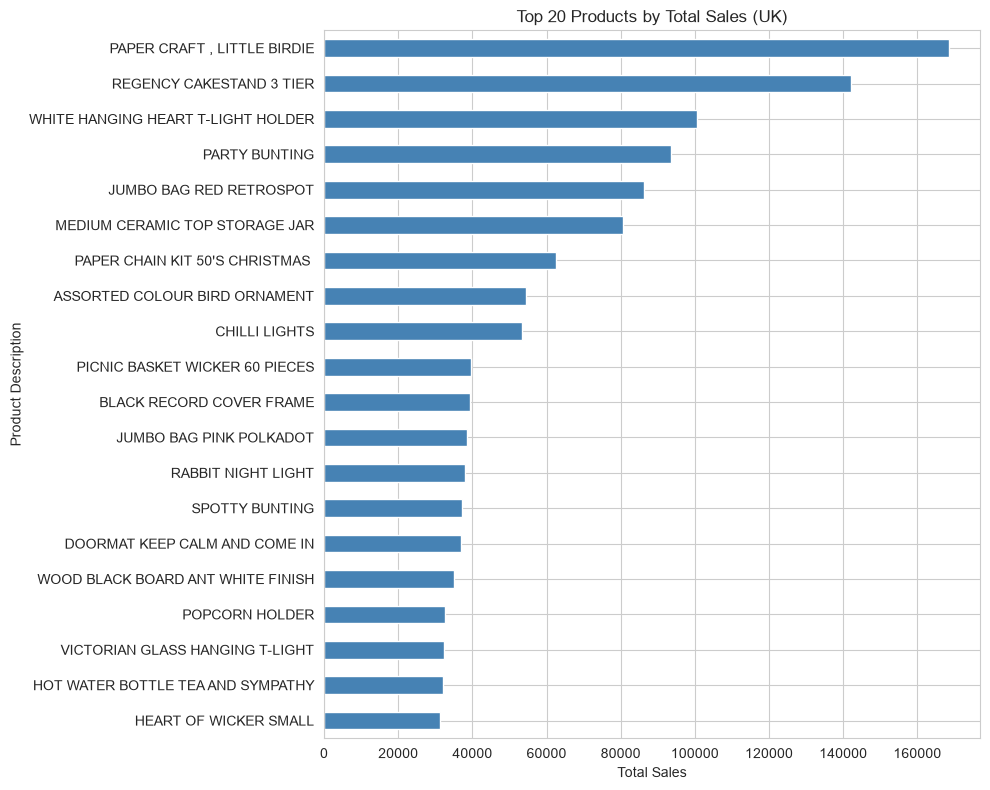

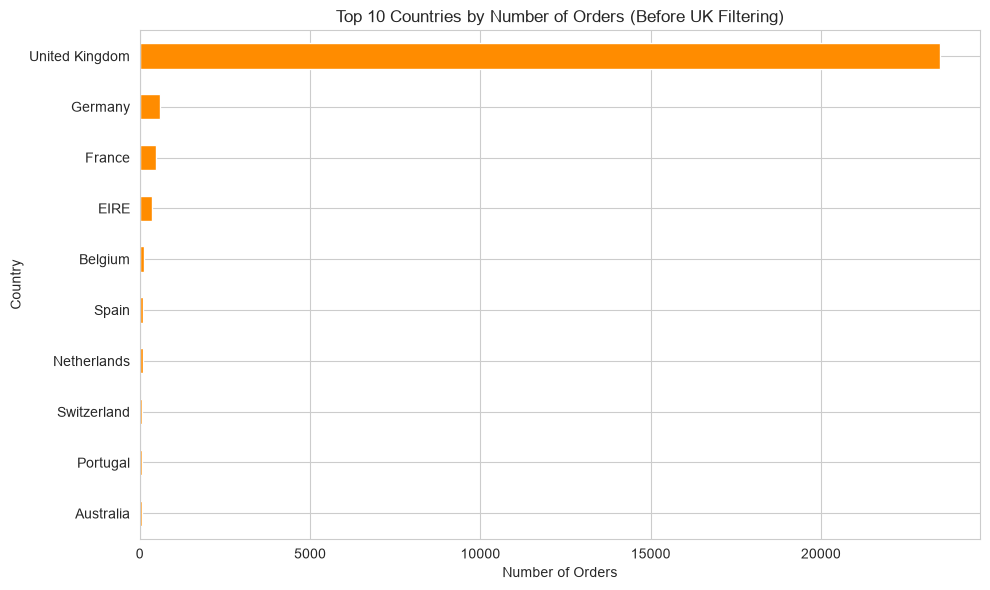

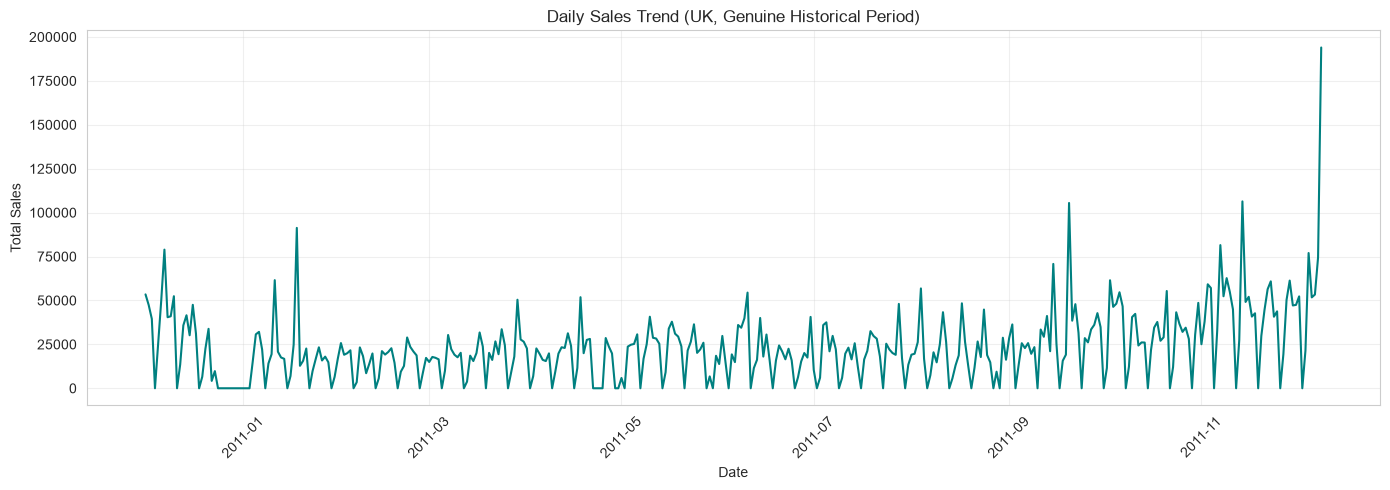

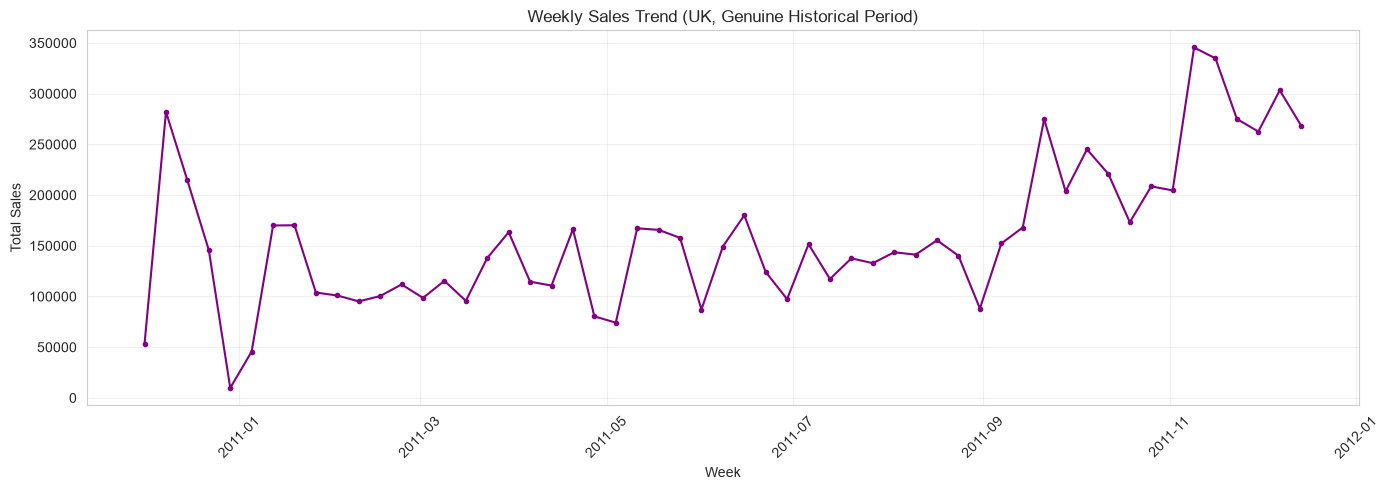

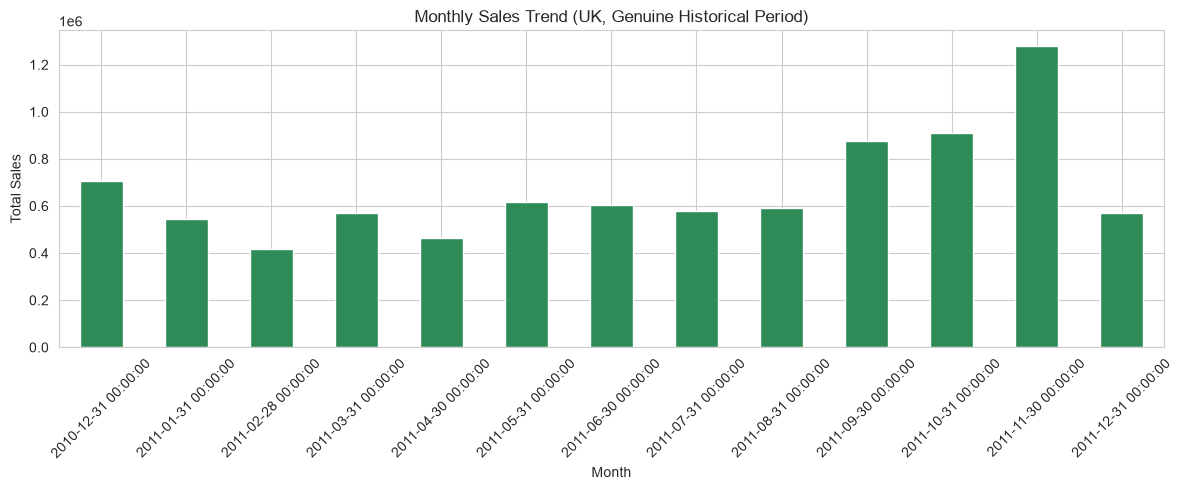

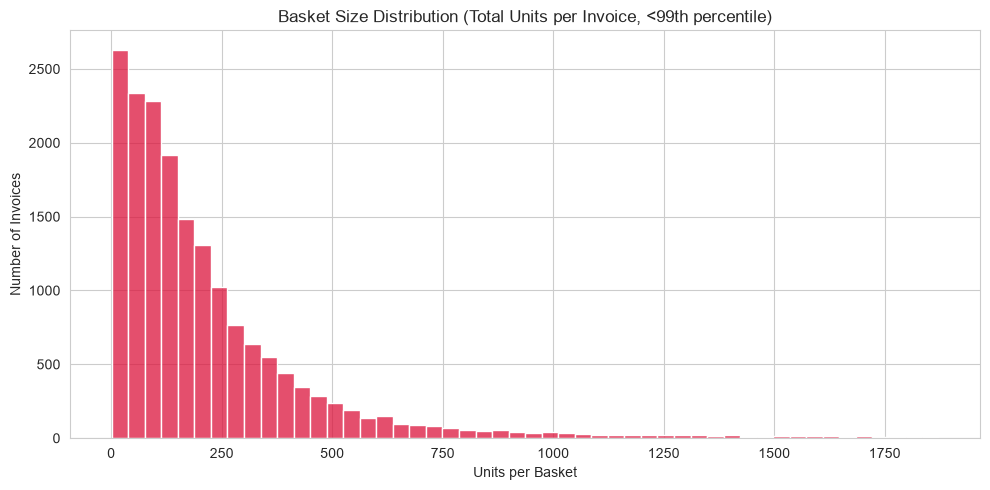


Basket size (units per invoice) summary statistics:


count    17903.000000
mean       259.137631
std        932.925504
min          1.000000
25%         68.000000
50%        146.000000
75%        284.000000
max      80995.000000
Name: Quantity, dtype: float64

In [5]:
print("Dataset shape (cleaned_uk):", cleaned_uk.shape)

print("\nMissing value summary:")
print(cleaned_uk.isna().sum())

print("\nDuplicate rows (post-cleaning):", cleaned_uk.duplicated().sum())

print("\nDescriptive statistics (numeric columns):")
display(cleaned_uk[["Quantity", "UnitPrice", "Sales"]].describe())

print(f"\nUnique customers: {cleaned_uk['CustomerID'].nunique()}")
print(f"Unique invoices : {cleaned_uk['InvoiceNo'].nunique()}")
print(f"Unique products : {cleaned_uk['StockCode'].nunique()}")
print(f"Total quantity  : {cleaned_uk['Quantity'].sum():,.0f}")
print(f"Total sales     : {cleaned_uk['Sales'].sum():,.2f}")
print(f"AOV             : {aov:,.2f}")

# Top 20 products by sales
top20_products = (
    cleaned_uk.groupby("Description")["Sales"].sum()
    .sort_values(ascending=False).head(20)
)
plt.figure(figsize=(10, 8))
top20_products.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 20 Products by Total Sales (UK)")
plt.xlabel("Total Sales")
plt.ylabel("Product Description")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top20_products_sales.png"), dpi=120)
plt.show()

# Top countries before UK filtering
top_countries = (
    step2.groupby("Country")["InvoiceNo"].nunique()
    .sort_values(ascending=False).head(10)
)
plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind="barh", color="darkorange")
plt.title("Top 10 Countries by Number of Orders (Before UK Filtering)")
plt.xlabel("Number of Orders")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_countries.png"), dpi=120)
plt.show()

# Daily sales trend
daily_sales = cleaned_uk.set_index("InvoiceDate")["Sales"].resample("D").sum()
plt.figure(figsize=(14, 5))
plt.plot(daily_sales.index, daily_sales.values, color="teal")
plt.title("Daily Sales Trend (UK, Genuine Historical Period)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "daily_sales_trend.png"), dpi=120)
plt.show()

# Weekly sales trend (preview; full weekly dataset built in Section 12)
weekly_sales_preview = cleaned_uk.set_index("InvoiceDate")["Sales"].resample("W-WED").sum()
plt.figure(figsize=(14, 5))
plt.plot(weekly_sales_preview.index, weekly_sales_preview.values,
         color="purple", marker="o", markersize=3)
plt.title("Weekly Sales Trend (UK, Genuine Historical Period)")
plt.xlabel("Week")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "weekly_sales_trend.png"), dpi=120)
plt.show()

# Monthly sales trend
monthly_sales = cleaned_uk.set_index("InvoiceDate")["Sales"].resample("ME").sum()
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="bar", color="seagreen")
plt.title("Monthly Sales Trend (UK, Genuine Historical Period)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "monthly_sales_trend.png"), dpi=120)
plt.show()

# Basket-size distribution (items per invoice)
basket_sizes = cleaned_uk.groupby("InvoiceNo")["Quantity"].sum()
plt.figure(figsize=(10, 5))
sns.histplot(basket_sizes[basket_sizes < basket_sizes.quantile(0.99)],
             bins=50, color="crimson")
plt.title("Basket Size Distribution (Total Units per Invoice, <99th percentile)")
plt.xlabel("Units per Basket")
plt.ylabel("Number of Invoices")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "basket_size_distribution.png"), dpi=120)
plt.show()

print("\nBasket size (units per invoice) summary statistics:")
display(basket_sizes.describe())

In [6]:
mba_data = cleaned_uk.dropna(subset=["Description"]).copy()
mba_data["Description"] = mba_data["Description"].astype(str).str.strip()

invoice_item_frequency = (
    mba_data.groupby("Description")["InvoiceNo"].nunique()
    .sort_values(ascending=False)
)
print("Top 10 products by invoice frequency:")
display(invoice_item_frequency.head(10))

# The top 120 products are retained to control Apriori computational
# complexity while preserving frequently purchased products.
TOP_N_PRODUCTS = 120
top_products = invoice_item_frequency.head(TOP_N_PRODUCTS).index.tolist()
mba_filtered = mba_data[mba_data["Description"].isin(top_products)].copy()

print(f"\nBaskets before item-universe restriction: {mba_data['InvoiceNo'].nunique()}")
print(f"Baskets retained after restricting to top {TOP_N_PRODUCTS} products: "
      f"{mba_filtered['InvoiceNo'].nunique()}")

# Build InvoiceNo x Description basket matrix
basket_lists = (
    mba_filtered.groupby("InvoiceNo")["Description"]
    .apply(lambda x: sorted(set(x)))
)
basket_lists = basket_lists[basket_lists.apply(len) > 0]

te = TransactionEncoder()
te_array = te.fit(basket_lists).transform(basket_lists)
basket_matrix = pd.DataFrame(te_array, columns=te.columns_, index=basket_lists.index)
basket_matrix = basket_matrix.astype(bool)

print(f"\nBasket matrix shape: {basket_matrix.shape}")

# Controlled search over support thresholds instead of one fixed value
support_grid = [0.01, 0.015, 0.02, 0.025, 0.03]
support_search_results = []
for sup in support_grid:
    itemsets_i = apriori(basket_matrix, min_support=sup, use_colnames=True)
    n_itemsets = len(itemsets_i)
    n_multi = (itemsets_i["itemsets"].apply(len) > 1).sum() if n_itemsets else 0
    support_search_results.append({
        "min_support": sup,
        "num_frequent_itemsets": n_itemsets,
        "num_multi_item_itemsets": n_multi,
    })

support_search_df = pd.DataFrame(support_search_results)
print("\nSupport threshold search:")
display(support_search_df)

candidates = support_search_df[
    (support_search_df["num_multi_item_itemsets"] >= 5) &
    (support_search_df["num_multi_item_itemsets"] <= 150)
]
if len(candidates) > 0:
    SELECTED_SUPPORT = candidates.sort_values("min_support").iloc[0]["min_support"]
else:
    # Fall back to the threshold producing the most multi-item itemsets
    SELECTED_SUPPORT = support_search_df.sort_values(
        "num_multi_item_itemsets", ascending=False).iloc[0]["min_support"]

print(f"\nSELECTED min_support = {SELECTED_SUPPORT}")

frequent_itemsets = apriori(basket_matrix, min_support=SELECTED_SUPPORT, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
print(f"Total frequent itemsets: {len(frequent_itemsets)}")
print(f"Multi-item itemsets: {(frequent_itemsets['length'] > 1).sum()}")

if len(frequent_itemsets) == 0:
    raise ValueError("No frequent itemsets found at the selected support level.")

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
rules = rules[rules["lift"] > 1].copy()
rules = rules.sort_values(
    ["lift", "confidence", "support"], ascending=[False, False, False]
).reset_index(drop=True)

def frozenset_to_str(fs):
    return ", ".join(sorted(fs))

rules["antecedents_str"] = rules["antecedents"].apply(frozenset_to_str)
rules["consequents_str"] = rules["consequents"].apply(frozenset_to_str)

rules_display = rules[[
    "antecedents_str", "consequents_str", "support", "confidence", "lift"
]].rename(columns={
    "antecedents_str": "antecedents",
    "consequents_str": "consequents",
})

print(f"\nTotal association rules (lift > 1, confidence >= 0.30): {len(rules_display)}")
print("\nTop 20 association rules:")
display(rules_display.head(20))

rules_display.to_csv(os.path.join(OUTPUT_DIR, "Market_Basket_Rules.csv"), index=False)
frequent_itemsets_export = frequent_itemsets.copy()
frequent_itemsets_export["itemsets"] = frequent_itemsets_export["itemsets"].apply(frozenset_to_str)
frequent_itemsets_export.to_csv(os.path.join(OUTPUT_DIR, "Frequent_Itemsets.csv"), index=False)

Top 10 products by invoice frequency:


Description
WHITE HANGING HEART T-LIGHT HOLDER    2162
JUMBO BAG RED RETROSPOT               1935
REGENCY CAKESTAND 3 TIER              1685
PARTY BUNTING                         1593
LUNCH BAG RED RETROSPOT               1392
ASSORTED COLOUR BIRD ORNAMENT         1371
SET OF 3 CAKE TINS PANTRY DESIGN      1241
NATURAL SLATE HEART CHALKBOARD        1219
LUNCH BAG  BLACK SKULL.               1216
HEART OF WICKER SMALL                 1164
Name: InvoiceNo, dtype: int64


Baskets before item-universe restriction: 17903
Baskets retained after restricting to top 120 products: 14763

Basket matrix shape: (14763, 120)

Support threshold search:


,min_support,num_frequent_itemsets,num_multi_item_itemsets
0,0.010,2011,1891
1,0.015,592,472
2,0.020,300,180
3,0.025,205,85
4,0.030,161,41



SELECTED min_support = 0.025
Total frequent itemsets: 205
Multi-item itemsets: 85

Total association rules (lift > 1, confidence >= 0.30): 154

Top 20 association rules:


,antecedents,consequents,support,confidence,lift
0,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.033327,0.700855,14.781026
1,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.033327,0.702857,14.781026
2,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.033327,0.527897,14.299713
3,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.033327,0.902752,14.299713
4,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.033327,0.854167,13.190442
5,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.033327,0.514644,13.190442
6,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.039016,0.618026,12.997029
7,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.039016,0.820513,12.997029
8,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.028856,0.609442,12.834798
9,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.028856,0.607703,12.834798


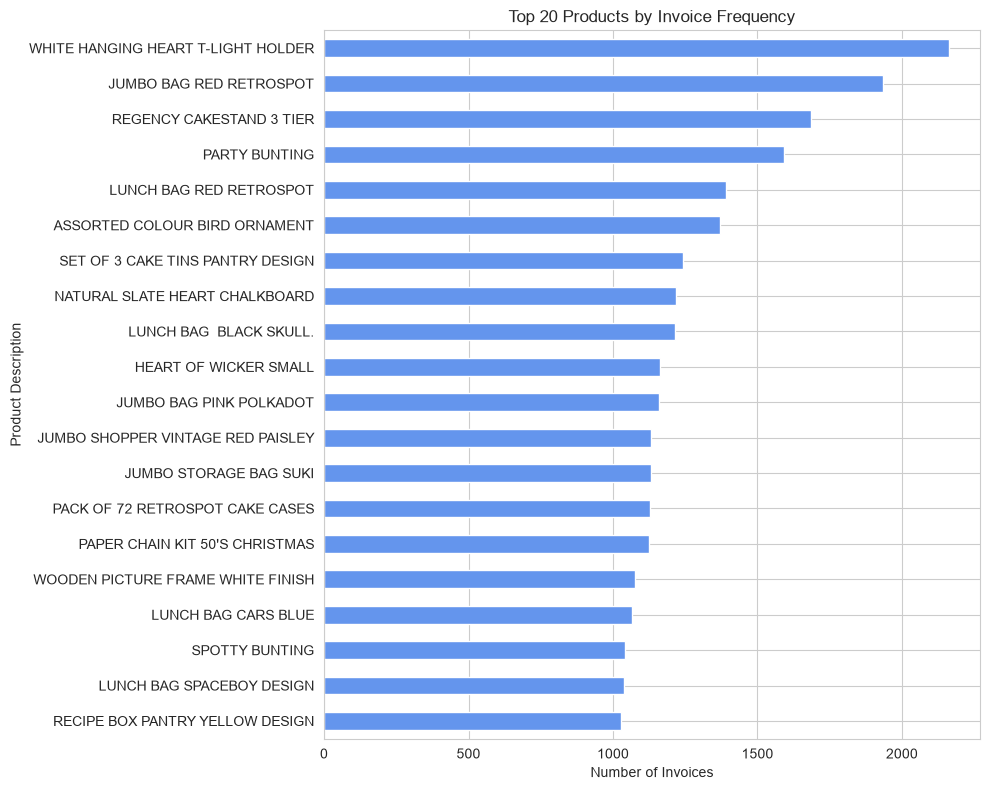

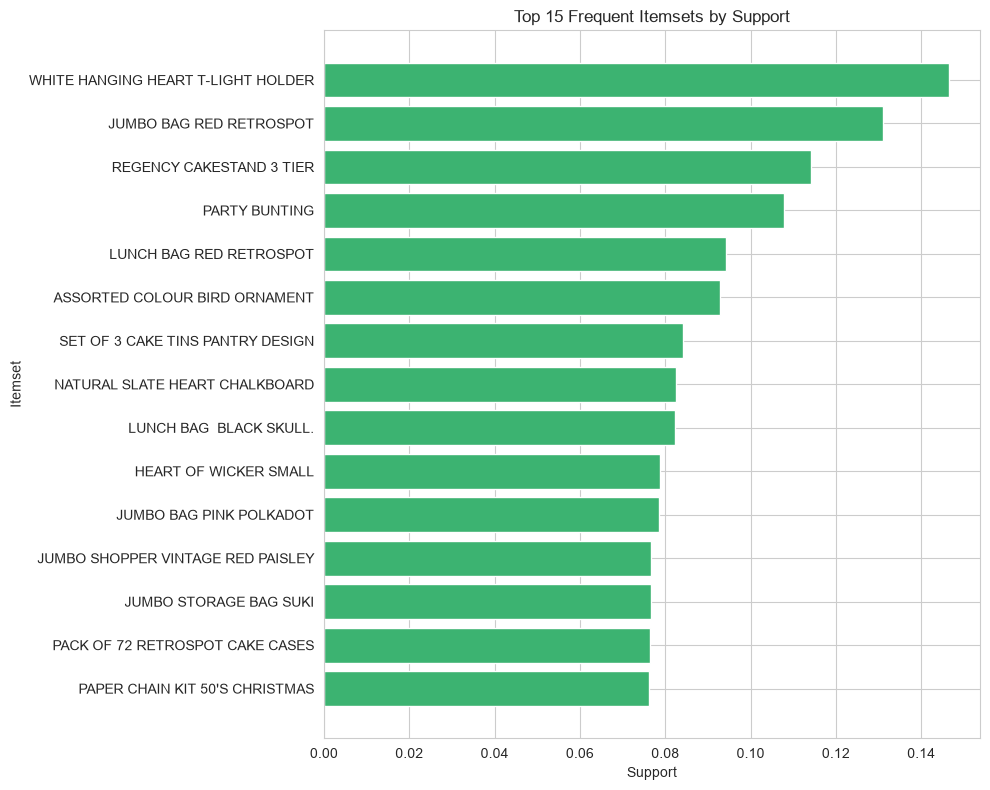

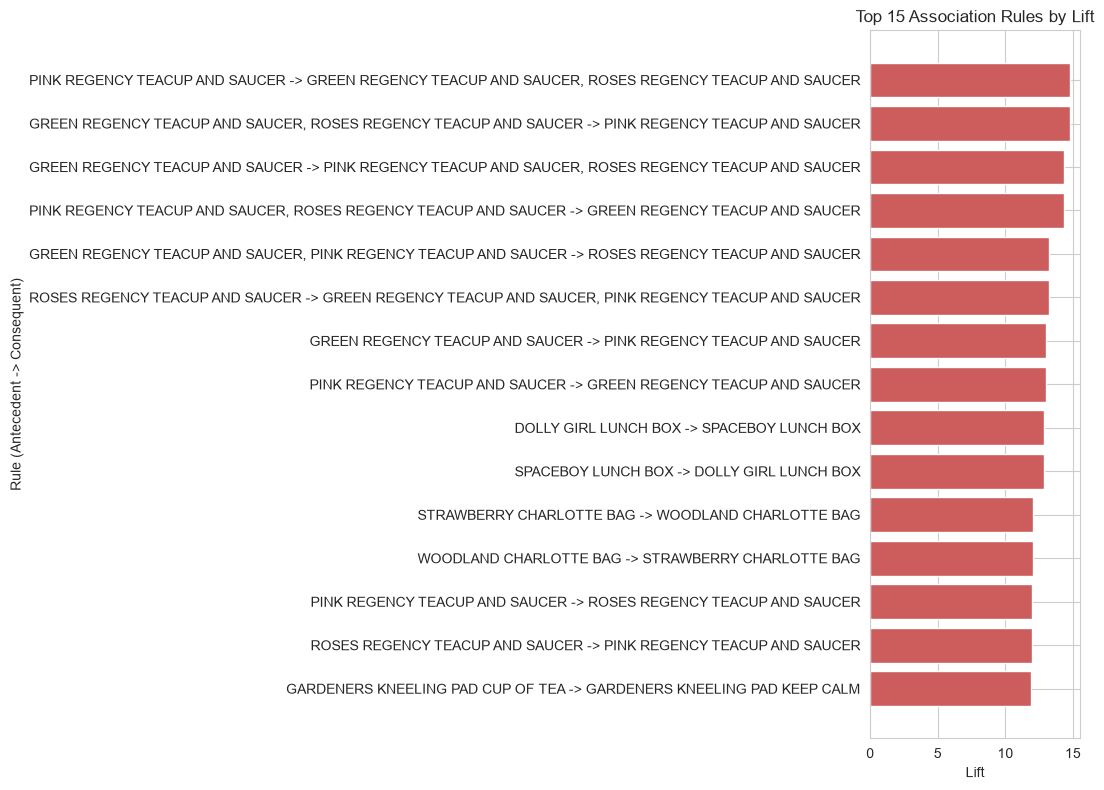

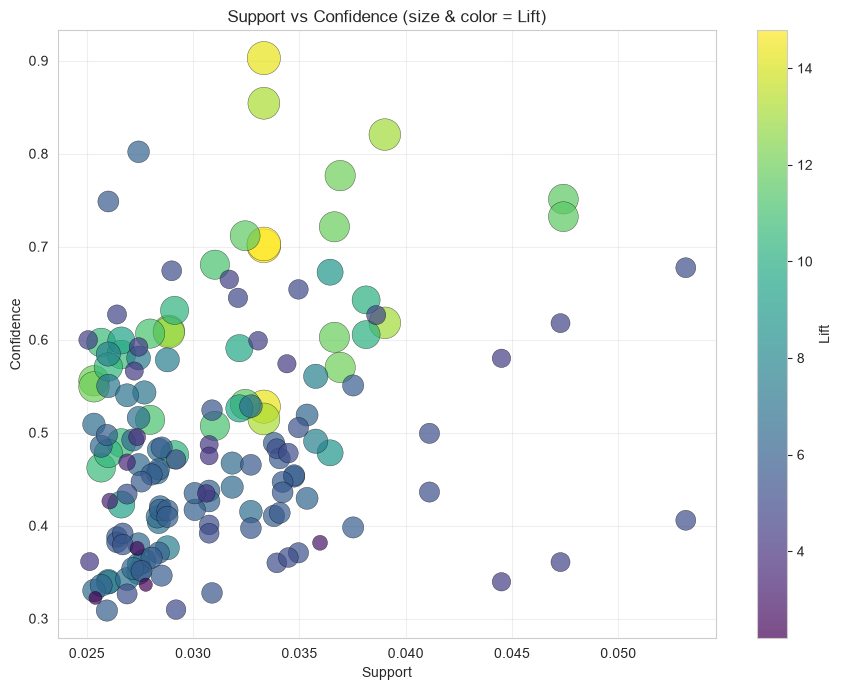

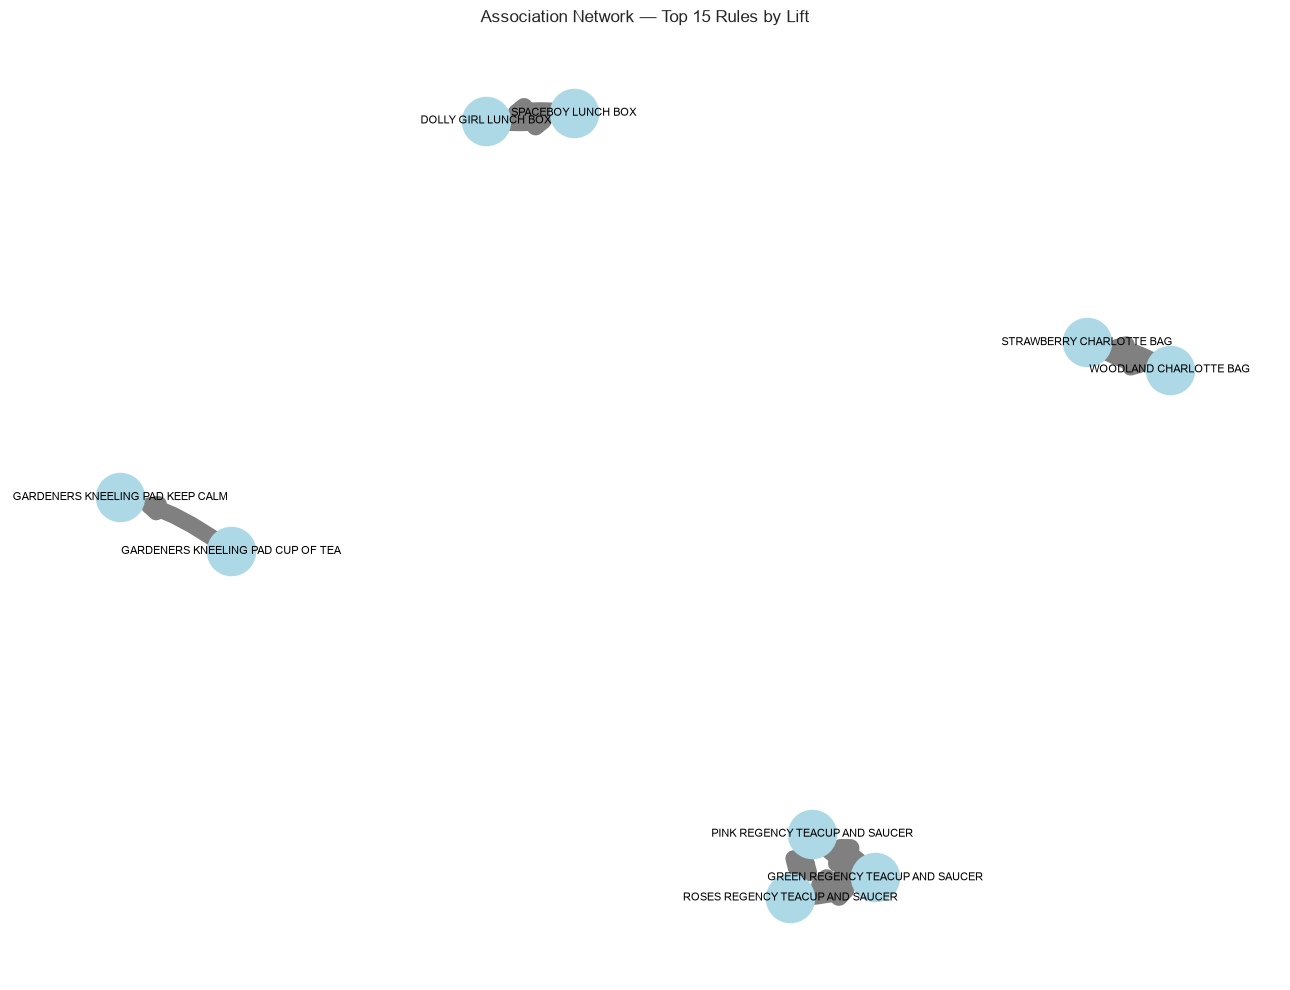

In [7]:
plt.figure(figsize=(10, 8))
invoice_item_frequency.head(20).sort_values().plot(kind="barh", color="cornflowerblue")
plt.title("Top 20 Products by Invoice Frequency")
plt.xlabel("Number of Invoices")
plt.ylabel("Product Description")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top20_product_frequency.png"), dpi=120)
plt.show()

# 2. Top frequent itemsets bar chart
top_itemsets_plot = frequent_itemsets.sort_values("support", ascending=False).head(15).copy()
top_itemsets_plot["itemsets_str"] = top_itemsets_plot["itemsets"].apply(frozenset_to_str)
plt.figure(figsize=(10, 8))
plt.barh(top_itemsets_plot["itemsets_str"], top_itemsets_plot["support"], color="mediumseagreen")
plt.title("Top 15 Frequent Itemsets by Support")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_frequent_itemsets.png"), dpi=120)
plt.show()

# 3. Top association rules by lift
if len(rules_display) > 0:
    top_rules_lift = rules_display.head(15).copy()
    top_rules_lift["rule_label"] = (
        top_rules_lift["antecedents"] + " -> " + top_rules_lift["consequents"]
    )
    plt.figure(figsize=(11, 8))
    plt.barh(top_rules_lift["rule_label"], top_rules_lift["lift"], color="indianred")
    plt.title("Top 15 Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule (Antecedent -> Consequent)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "top_rules_by_lift.png"), dpi=120)
    plt.show()

    # 4. Support vs Confidence scatter, sized/colored by lift
    plt.figure(figsize=(9, 7))
    scatter = plt.scatter(
        rules["support"], rules["confidence"],
        s=rules["lift"] * 40, c=rules["lift"], cmap="viridis", alpha=0.7,
        edgecolors="black", linewidths=0.3
    )
    plt.colorbar(scatter, label="Lift")
    plt.title("Support vs Confidence (size & color = Lift)")
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "support_confidence_scatter.png"), dpi=120)
    plt.show()

    # 5. NetworkX association graph using only the strongest rules (top 15)
    TOP_N_GRAPH_RULES = 15
    graph_rules = rules.sort_values("lift", ascending=False).head(TOP_N_GRAPH_RULES)

    G = nx.DiGraph()
    for _, row in graph_rules.iterrows():
        for a in row["antecedents"]:
            for c in row["consequents"]:
                G.add_edge(a, c, weight=row["lift"])

    if G.number_of_nodes() > 0:
        plt.figure(figsize=(13, 10))
        pos = nx.spring_layout(G, k=0.8, seed=RANDOM_STATE)
        weights = [G[u][v]["weight"] for u, v in G.edges()]
        nx.draw_networkx_nodes(G, pos, node_size=1200, node_color="lightblue")
        nx.draw_networkx_labels(G, pos, font_size=8)
        nx.draw_networkx_edges(
            G, pos, width=[w for w in weights], edge_color="gray",
            arrows=True, arrowsize=15, connectionstyle="arc3,rad=0.1"
        )
        plt.title(f"Association Network — Top {TOP_N_GRAPH_RULES} Rules by Lift")
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "association_network.png"), dpi=120)
        plt.show()
else:
    print("No rules met the lift/confidence thresholds; visualizations skipped.")

In [8]:
print("MARKET BASKET METRIC DEFINITIONS")
print("Support: the proportion of baskets containing the itemset.")
print("Confidence: the probability of purchasing the consequent given the "
      "antecedent is present in the basket.")
print("Lift: how much more frequently the antecedent and consequent occur "
      "together compared with what would be expected if they were "
      "statistically independent.")
print("Interpretation rule: Lift > 1 = positive association; "
      "Lift ~ 1 = approximately independent; Lift < 1 = negative association.")
print("\nIMPORTANT: Association does not imply causation. These rules "
      "describe co-occurrence patterns in observed transactions only.")

bundle_recommendations = rules_display.head(10).copy()
bundle_recommendations["Recommended marketing action"] = (
    "Cross-sell/bundle '" + bundle_recommendations["consequents"] +
    "' with '" + bundle_recommendations["antecedents"] +
    "' (e.g. co-location, 'frequently bought together' prompts, bundle pricing)."
)
bundle_recommendations = bundle_recommendations.rename(columns={
    "antecedents": "Antecedent", "consequents": "Consequent",
    "support": "Support", "confidence": "Confidence", "lift": "Lift",
})

print("\nBundling recommendations (derived strictly from generated rules):")
display(bundle_recommendations)

MARKET BASKET METRIC DEFINITIONS
Support: the proportion of baskets containing the itemset.
Confidence: the probability of purchasing the consequent given the antecedent is present in the basket.
Lift: how much more frequently the antecedent and consequent occur together compared with what would be expected if they were statistically independent.
Interpretation rule: Lift > 1 = positive association; Lift ~ 1 = approximately independent; Lift < 1 = negative association.

IMPORTANT: Association does not imply causation. These rules describe co-occurrence patterns in observed transactions only.

Bundling recommendations (derived strictly from generated rules):


,Antecedent,Consequent,Support,Confidence,Lift,Recommended marketing action
0,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.033327,0.700855,14.781026,Cross-sell/bundle 'GREEN REGENCY TEACUP AND SA...
1,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.033327,0.702857,14.781026,Cross-sell/bundle 'PINK REGENCY TEACUP AND SAU...
2,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.033327,0.527897,14.299713,Cross-sell/bundle 'PINK REGENCY TEACUP AND SAU...
3,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.033327,0.902752,14.299713,Cross-sell/bundle 'GREEN REGENCY TEACUP AND SA...
4,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.033327,0.854167,13.190442,Cross-sell/bundle 'ROSES REGENCY TEACUP AND SA...
5,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.033327,0.514644,13.190442,Cross-sell/bundle 'GREEN REGENCY TEACUP AND SA...
6,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.039016,0.618026,12.997029,Cross-sell/bundle 'PINK REGENCY TEACUP AND SAU...
7,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.039016,0.820513,12.997029,Cross-sell/bundle 'GREEN REGENCY TEACUP AND SA...
8,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.028856,0.609442,12.834798,Cross-sell/bundle 'SPACEBOY LUNCH BOX' with 'D...
9,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.028856,0.607703,12.834798,Cross-sell/bundle 'DOLLY GIRL LUNCH BOX' with ...


In [9]:
week_start_anchor = pd.Timestamp("2010-12-01")
last_date = GENUINE_END.normalize()
n_weeks = int(np.ceil((last_date - week_start_anchor).days / 7)) + 1

week_bounds = []
for w in range(n_weeks):
    w_start = week_start_anchor + pd.Timedelta(days=7 * w)
    w_end = w_start + pd.Timedelta(days=6, hours=23, minutes=59, seconds=59)
    if w_start > GENUINE_END:
        break
    week_bounds.append((w + 1, w_start, min(w_end, GENUINE_END)))

week_map_df = pd.DataFrame(week_bounds, columns=["Week_Number", "Week_Start", "Week_End"])
print(f"Number of sequential weekly bins created: {len(week_map_df)}")
display(week_map_df.head())

def assign_week(ts):
    delta_days = (ts.normalize() - week_start_anchor).days
    return int(delta_days // 7) + 1

# Full transaction-level frame (including cancellations) restricted to
# genuine period + UK, used to compute cancellation rate correctly.
uk_all_period = step2.copy()  # UK filter not yet applied here; apply now
uk_all_period = uk_all_period[uk_all_period["Country"].astype(str).str.strip() == "United Kingdom"].copy()
uk_all_period["Week_Number"] = uk_all_period["InvoiceDate"].apply(assign_week)

cleaned_uk["Week_Number"] = cleaned_uk["InvoiceDate"].apply(assign_week)

weekly_agg = cleaned_uk.groupby("Week_Number").agg(
    Total_Sales=("Sales", "sum"),
    Num_Orders=("InvoiceNo", "nunique"),
    Num_Customers=("CustomerID", "nunique"),
    Total_Quantity=("Quantity", "sum"),
    Num_Unique_Products=("StockCode", "nunique"),
    Avg_Unit_Price=("UnitPrice", "mean"),
).reset_index()

weekly_agg["AOV"] = weekly_agg["Total_Sales"] / weekly_agg["Num_Orders"].replace(0, np.nan)

weekly_df = week_map_df.merge(weekly_agg, on="Week_Number", how="left")
# Weeks with genuinely zero UK transactions become 0 (not NaN) for count fields
count_cols = ["Total_Sales", "Num_Orders", "Num_Customers", "Total_Quantity",
              "Num_Unique_Products"]
weekly_df[count_cols] = weekly_df[count_cols].fillna(0)

print(f"\nWeekly dataset shape: {weekly_df.shape}")
display(weekly_df.head())

Number of sequential weekly bins created: 54


,Week_Number,Week_Start,Week_End
0,1,2010-12-01,2010-12-07 23:59:59
1,2,2010-12-08,2010-12-14 23:59:59
2,3,2010-12-15,2010-12-21 23:59:59
3,4,2010-12-22,2010-12-28 23:59:59
4,5,2010-12-29,2011-01-04 23:59:59



Weekly dataset shape: (54, 10)


,Week_Number,Week_Start,Week_End,Total_Sales,Num_Orders,Num_Customers,Total_Quantity,Num_Unique_Products,Avg_Unit_Price,AOV
0,1,2010-12-01,2010-12-07 23:59:59,294990.19,567,393,124960,2281,3.808494,520.264885
1,2,2010-12-08,2010-12-14 23:59:59,224718.06,473,351,99900,2193,3.698888,475.091036
2,3,2010-12-15,2010-12-21 23:59:59,171701.30,362,246,80917,2061,4.303825,474.312983
3,4,2010-12-22,2010-12-28 23:59:59,13949.89,38,23,6927,798,3.380426,367.102368
4,5,2010-12-29,2011-01-04 23:59:59,14977.32,35,33,8329,812,3.214297,427.923429


In [10]:
cust_period = cleaned_uk.dropna(subset=["CustomerID"]).copy()
cust_period = cust_period.sort_values("InvoiceDate")

first_purchase_week = cust_period.groupby("CustomerID")["Week_Number"].min()

weekly_customers = cust_period.groupby("Week_Number")["CustomerID"].apply(set)

repeat_rates = []
seen_customers = set()
for wk in sorted(weekly_customers.index):
    current_customers = weekly_customers[wk]
    repeat_customers = current_customers & seen_customers
    rate = len(repeat_customers) / len(current_customers) if len(current_customers) > 0 else 0.0
    repeat_rates.append({"Week_Number": wk, "Repeat_Customer_Rate": rate})
    seen_customers = seen_customers | current_customers

repeat_rate_df = pd.DataFrame(repeat_rates)
weekly_df = weekly_df.merge(repeat_rate_df, on="Week_Number", how="left")
weekly_df["Repeat_Customer_Rate"] = weekly_df["Repeat_Customer_Rate"].fillna(0.0)

In [11]:
cancellations_df["Week_Number"] = cancellations_df["InvoiceDate"].apply(assign_week)

cancelled_invoices_per_week = cancellations_df.groupby("Week_Number")["InvoiceNo"].nunique()
valid_invoices_per_week = uk_all_period[~uk_all_period["InvoiceNo"].astype(str).str.startswith("C")] \
    .groupby("Week_Number")["InvoiceNo"].nunique()

cancel_rate_df = pd.DataFrame({
    "Cancelled_Invoices": cancelled_invoices_per_week,
    "Valid_Invoices": valid_invoices_per_week,
}).fillna(0)
cancel_rate_df["Total_Invoices"] = cancel_rate_df["Cancelled_Invoices"] + cancel_rate_df["Valid_Invoices"]
cancel_rate_df["Cancellation_Rate"] = np.where(
    cancel_rate_df["Total_Invoices"] > 0,
    cancel_rate_df["Cancelled_Invoices"] / cancel_rate_df["Total_Invoices"],
    0.0
)
cancel_rate_df = cancel_rate_df.reset_index().rename(columns={"index": "Week_Number"})

weekly_df = weekly_df.merge(
    cancel_rate_df[["Week_Number", "Cancellation_Rate"]], on="Week_Number", how="left"
)
weekly_df["Cancellation_Rate"] = weekly_df["Cancellation_Rate"].fillna(0.0)

print("Cancellation and repeat-customer rate summary (first 10 weeks):")
display(weekly_df[["Week_Number", "Week_Start", "Repeat_Customer_Rate",
                    "Cancellation_Rate"]].head(10))

Cancellation and repeat-customer rate summary (first 10 weeks):


,Week_Number,Week_Start,Repeat_Customer_Rate,Cancellation_Rate
0,1,2010-12-01,0.000000,0.104079
1,2,2010-12-08,0.230769,0.190332
2,3,2010-12-15,0.422764,0.185185
3,4,2010-12-22,0.608696,0.245283
4,5,2010-12-29,0.606061,0.109091
5,6,2011-01-05,0.520930,0.166205
6,7,2011-01-12,0.556818,0.155797
7,8,2011-01-19,0.525140,0.200669
8,9,2011-01-26,0.518349,0.167070
9,10,2011-02-02,0.566138,0.080139


In [12]:
weekly_df["Month"] = weekly_df["Week_Start"].dt.month
weekly_df["Week_of_Year"] = weekly_df["Week_Start"].dt.isocalendar().week.astype(int)
# November-December peak season
weekly_df["Holiday_Flag"] = weekly_df["Month"].isin([11, 12]).astype(int)

print(f"Weeks flagged as holiday/peak season: {weekly_df['Holiday_Flag'].sum()} "
      f"of {len(weekly_df)}")

Weeks flagged as holiday/peak season: 11 of 54


In [13]:
weekly_df = weekly_df.sort_values("Week_Number").reset_index(drop=True)
weekly_df["Weekly_Sales_Growth"] = weekly_df["Total_Sales"].pct_change() * 100

print("Weekly sales-driver dataset (final columns):")
display(weekly_df.head())
print(f"\nTotal weekly observations: {len(weekly_df)}")

weekly_df.to_csv(os.path.join(OUTPUT_DIR, "Weekly_Sales_Drivers_Dataset.csv"), index=False)

Weekly sales-driver dataset (final columns):


,Week_Number,Week_Start,Week_End,Total_Sales,Num_Orders,Num_Customers,Total_Quantity,Num_Unique_Products,Avg_Unit_Price,AOV,Repeat_Customer_Rate,Cancellation_Rate,Month,Week_of_Year,Holiday_Flag,Weekly_Sales_Growth
0,1,2010-12-01,2010-12-07 23:59:59,294990.19,567,393,124960,2281,3.808494,520.264885,0.000000,0.104079,12,48,1,NaN
1,2,2010-12-08,2010-12-14 23:59:59,224718.06,473,351,99900,2193,3.698888,475.091036,0.230769,0.190332,12,49,1,-23.821853
2,3,2010-12-15,2010-12-21 23:59:59,171701.30,362,246,80917,2061,4.303825,474.312983,0.422764,0.185185,12,50,1,-23.592568
3,4,2010-12-22,2010-12-28 23:59:59,13949.89,38,23,6927,798,3.380426,367.102368,0.608696,0.245283,12,51,1,-91.875490
4,5,2010-12-29,2011-01-04 23:59:59,14977.32,35,33,8329,812,3.214297,427.923429,0.606061,0.109091,12,52,1,7.365148



Total weekly observations: 54


In [14]:
mmm_df = weekly_df.copy()
mmm_df["Trend"] = np.arange(1, len(mmm_df) + 1)

mmm_df["Month_sin"] = np.sin(2 * np.pi * mmm_df["Month"] / 12)
mmm_df["Month_cos"] = np.cos(2 * np.pi * mmm_df["Month"] / 12)
seasonality_cols = ["Month_sin", "Month_cos"]

print("Seasonality columns created (cyclical encoding, chosen for the small "
      "sample size instead of 11 month dummies):", seasonality_cols)

Seasonality columns created (cyclical encoding, chosen for the small sample size instead of 11 month dummies): ['Month_sin', 'Month_cos']


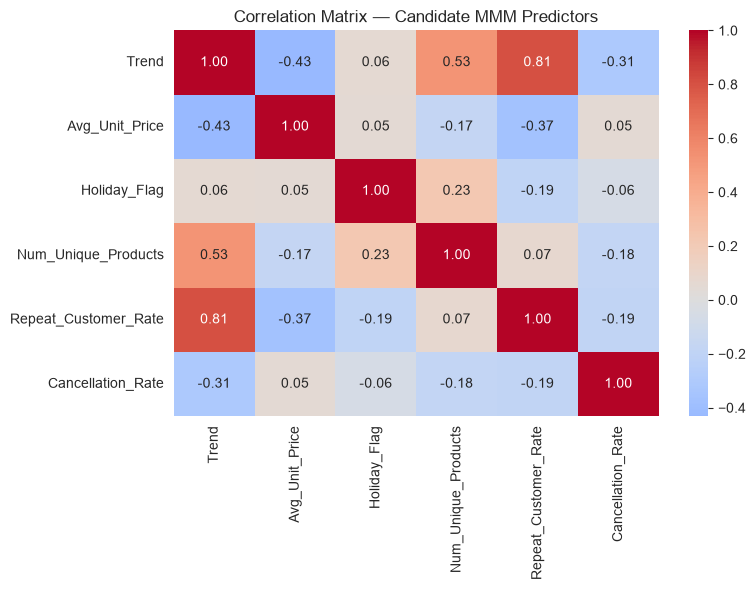


Variance Inflation Factor (VIF) table:


,Feature,VIF
0,Trend,9.584656
1,Avg_Unit_Price,1.259006
2,Holiday_Flag,1.231245
3,Num_Unique_Products,2.806701
4,Repeat_Customer_Rate,6.623794
5,Cancellation_Rate,1.142881



No predictor exceeds the VIF threshold of 10; multicollinearity among core MMM predictors is not a material concern.

Final core MMM predictor list: ['Trend', 'Avg_Unit_Price', 'Holiday_Flag', 'Num_Unique_Products', 'Repeat_Customer_Rate', 'Cancellation_Rate']


In [15]:
candidate_predictors = [
    "Trend", "Avg_Unit_Price", "Holiday_Flag", "Num_Unique_Products",
    "Repeat_Customer_Rate", "Cancellation_Rate"
] + seasonality_cols

corr_matrix = mmm_df[["Trend", "Avg_Unit_Price", "Holiday_Flag",
                       "Num_Unique_Products", "Repeat_Customer_Rate",
                       "Cancellation_Rate"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Candidate MMM Predictors")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "correlation_matrix.png"), dpi=120)
plt.show()

def compute_vif(data, cols):
    # Manual VIF (no statsmodels dependency): for each predictor, regress it
    # on all remaining predictors with an ordinary least-squares LinearRegression
    # and derive VIF_i = 1 / (1 - R_i^2). This is mathematically identical to
    # statsmodels' variance_inflation_factor but avoids a fragile external
    # dependency that can break with scipy/statsmodels version mismatches.
    X_vif = data[cols].copy()
    X_vif = X_vif.fillna(X_vif.mean())
    vif_rows = []
    for target_col in X_vif.columns:
        other_cols = [c for c in X_vif.columns if c != target_col]
        lr_vif = LinearRegression()
        lr_vif.fit(X_vif[other_cols], X_vif[target_col])
        r2 = lr_vif.score(X_vif[other_cols], X_vif[target_col])
        vif_value = 1.0 / (1.0 - r2) if r2 < 1.0 else np.inf
        vif_rows.append({"Feature": target_col, "VIF": vif_value})
    return pd.DataFrame(vif_rows)

vif_table = compute_vif(mmm_df, ["Trend", "Avg_Unit_Price", "Holiday_Flag",
                                  "Num_Unique_Products", "Repeat_Customer_Rate",
                                  "Cancellation_Rate"])
print("\nVariance Inflation Factor (VIF) table:")
display(vif_table)

HIGH_VIF_THRESHOLD = 10
high_vif_features = vif_table[vif_table["VIF"] > HIGH_VIF_THRESHOLD]["Feature"].tolist()
if high_vif_features:
    print(f"\nFeatures with VIF > {HIGH_VIF_THRESHOLD} (potential multicollinearity): "
          f"{high_vif_features}")
    print("These are flagged rather than blindly dropped; each is reviewed for "
          "conceptual importance before removal.")
else:
    print(f"\nNo predictor exceeds the VIF threshold of {HIGH_VIF_THRESHOLD}; "
          "multicollinearity among core MMM predictors is not a material concern.")

# Final predictor list: drop any flagged predictor ONLY if it is not the sole
# representation of a required conceptual driver (Holiday_Flag/Repeat/Cancellation/
# Num_Unique_Products/Avg_Unit_Price are all required by the brief and retained;
# Trend is retained as the core time-control variable).
final_core_predictors = ["Trend", "Avg_Unit_Price", "Holiday_Flag",
                          "Num_Unique_Products", "Repeat_Customer_Rate",
                          "Cancellation_Rate"]
print(f"\nFinal core MMM predictor list: {final_core_predictors}")

In [16]:
skew_check_cols = ["Total_Sales", "Avg_Unit_Price", "Num_Unique_Products"]
skew_table = mmm_df[skew_check_cols].skew()
print("Skewness of key variables:")
display(skew_table)

SKEW_THRESHOLD = 1.0
# Log-transform the target if heavily right-skewed
LOG_TARGET = abs(skew_table["Total_Sales"]) > SKEW_THRESHOLD
if LOG_TARGET:
    mmm_df["Total_Sales_Model"] = np.log1p(mmm_df["Total_Sales"])
    print("\nTotal_Sales is heavily skewed -> using log1p(Total_Sales) as the "
          "modelling target (labelled Total_Sales_Model).")
else:
    mmm_df["Total_Sales_Model"] = mmm_df["Total_Sales"]
    print("\nTotal_Sales skewness within acceptable range -> using raw Total_Sales "
          "as the modelling target.")

# Log-transform heavily skewed positive predictors only (never binary flags)
for col in ["Avg_Unit_Price", "Num_Unique_Products"]:
    if abs(mmm_df[col].skew()) > SKEW_THRESHOLD:
        mmm_df[f"{col}_log"] = np.log1p(mmm_df[col])
        print(f"{col} is skewed -> created log1p transformed version {col}_log.")

Skewness of key variables:


Total_Sales            0.660325
Avg_Unit_Price         2.366039
Num_Unique_Products   -0.946414
dtype: float64


Total_Sales skewness within acceptable range -> using raw Total_Sales as the modelling target.
Avg_Unit_Price is skewed -> created log1p transformed version Avg_Unit_Price_log.


In [17]:
mmm_df = mmm_df.sort_values("Week_Number").reset_index(drop=True)
n_total = len(mmm_df)
n_train = int(np.floor(n_total * 0.8))

train_df = mmm_df.iloc[:n_train].copy()
test_df = mmm_df.iloc[n_train:].copy()

print(f"Total weekly observations: {n_total}")
print(f"Training observations (chronological, first 80%): {len(train_df)}")
print(f"Testing observations (chronological, last 20%): {len(test_df)}")

TARGET_COL = "Total_Sales_Model"

baseline_predictors = ["Trend", "Avg_Unit_Price", "Holiday_Flag"] + seasonality_cols
mmm_predictors = ["Trend", "Avg_Unit_Price", "Holiday_Flag",
                   "Num_Unique_Products", "Repeat_Customer_Rate",
                   "Cancellation_Rate"] + seasonality_cols

def get_X_y(data, predictors, target=TARGET_COL, impute_values=None):
    # impute_values must be learned from TRAINING data only, then reused for
    # the test split. Computing means independently on train and test causes
    # preprocessing leakage (test-set statistics influencing its own inputs).
    X = data[predictors].copy()
    if impute_values is None:
        impute_values = X.mean()
    X = X.fillna(impute_values)
    y = data[target].copy()
    return X, y

# Baseline predictor set: learn impute values from train, apply to both splits
base_impute_values = train_df[baseline_predictors].mean()
X_train_base, y_train = get_X_y(train_df, baseline_predictors,
                                 impute_values=base_impute_values)
X_test_base, y_test = get_X_y(test_df, baseline_predictors,
                               impute_values=base_impute_values)

# MMM predictor set: learn impute values from train, apply to both splits
mmm_impute_values = train_df[mmm_predictors].mean()
X_train_mmm, _ = get_X_y(train_df, mmm_predictors,
                          impute_values=mmm_impute_values)
X_test_mmm, _ = get_X_y(test_df, mmm_predictors,
                         impute_values=mmm_impute_values)

def inverse_target(y_arr):
    return np.expm1(y_arr) if LOG_TARGET else y_arr

Total weekly observations: 54
Training observations (chronological, first 80%): 43
Testing observations (chronological, last 20%): 11


In [18]:
model_results = []

def evaluate_model(name, y_true_log, y_pred_log):
    y_true = inverse_target(y_true_log)
    y_pred = inverse_target(np.asarray(y_pred_log))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    model_results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
    return rmse, mae, r2, y_pred

baseline_lr = LinearRegression().fit(X_train_base, y_train)
baseline_pred = baseline_lr.predict(X_test_base)
base_rmse, base_mae, base_r2, base_pred_actual = evaluate_model(
    "1. Baseline Linear Regression", y_test, baseline_pred)
print(f"Baseline model  -> RMSE: {base_rmse:,.2f}  MAE: {base_mae:,.2f}  R2: {base_r2:.3f}")

mmm_lr = LinearRegression().fit(X_train_mmm, y_train)
mmm_pred = mmm_lr.predict(X_test_mmm)
mmm_rmse, mmm_mae, mmm_r2, mmm_pred_actual = evaluate_model(
    "2. Marketing Mix Linear Regression", y_test, mmm_pred)
print(f"MMM model       -> RMSE: {mmm_rmse:,.2f}  MAE: {mmm_mae:,.2f}  R2: {mmm_r2:.3f}")

print("\nBASELINE vs MARKETING MIX MODEL COMPARISON")
if mmm_r2 > base_r2:
    print("Adding internal sales-driver variables (product breadth, repeat-"
          "customer rate, cancellation rate) IMPROVES predictive performance "
          "beyond the baseline of trend, seasonality and price alone.")
else:
    print("Adding internal sales-driver variables does NOT clearly improve "
          "predictive performance beyond the baseline in this sample; this may "
          "reflect the small number of weekly observations available.")

Baseline model  -> RMSE: 137,385.67  MAE: 119,478.85  R2: -5.411
MMM model       -> RMSE: 49,997.88  MAE: 39,871.54  R2: 0.151

BASELINE vs MARKETING MIX MODEL COMPARISON
Adding internal sales-driver variables (product breadth, repeat-customer rate, cancellation rate) IMPROVES predictive performance beyond the baseline of trend, seasonality and price alone.


In [19]:
scaler = StandardScaler()
X_train_mmm_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_mmm), columns=X_train_mmm.columns, index=X_train_mmm.index
)
X_test_mmm_scaled = pd.DataFrame(
    scaler.transform(X_test_mmm), columns=X_test_mmm.columns, index=X_test_mmm.index
)

tscv = TimeSeriesSplit(n_splits=min(5, max(2, len(X_train_mmm) // 6)))

def tune_model(model_class, param_grid, X, y, tscv):
    best_score = -np.inf
    best_params = None
    for alpha in param_grid:
        fold_scores = []
        for train_idx, val_idx in tscv.split(X):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
            m = model_class(alpha=alpha, random_state=RANDOM_STATE) \
                if model_class.__name__ == "Lasso" else model_class(alpha=alpha)
            m.fit(X_tr, y_tr)
            pred = m.predict(X_val)
            fold_scores.append(r2_score(y_val, pred))
        mean_score = np.mean(fold_scores)
        if mean_score > best_score:
            best_score = mean_score
            best_params = alpha
    return best_params, best_score

ridge_alpha_grid = [0.01, 0.1, 1, 10, 50, 100]
best_ridge_alpha, ridge_cv_score = tune_model(Ridge, ridge_alpha_grid, X_train_mmm_scaled, y_train, tscv)
print(f"Best Ridge alpha (TimeSeriesSplit CV): {best_ridge_alpha} "
      f"(mean CV R2: {ridge_cv_score:.3f})")

ridge_model = Ridge(alpha=best_ridge_alpha).fit(X_train_mmm_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_mmm_scaled)
ridge_rmse, ridge_mae, ridge_r2, ridge_pred_actual = evaluate_model(
    "3. Ridge Regression", y_test, ridge_pred)
print(f"Ridge model     -> RMSE: {ridge_rmse:,.2f}  MAE: {ridge_mae:,.2f}  R2: {ridge_r2:.3f}")

lasso_alpha_grid = [0.001, 0.01, 0.05, 0.1, 0.5, 1]
best_lasso_alpha, lasso_cv_score = tune_model(Lasso, lasso_alpha_grid, X_train_mmm_scaled, y_train, tscv)
print(f"Best Lasso alpha (TimeSeriesSplit CV): {best_lasso_alpha} "
      f"(mean CV R2: {lasso_cv_score:.3f})")

lasso_model = Lasso(alpha=best_lasso_alpha, random_state=RANDOM_STATE).fit(X_train_mmm_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_mmm_scaled)
lasso_rmse, lasso_mae, lasso_r2, lasso_pred_actual = evaluate_model(
    "4. Lasso Regression", y_test, lasso_pred)
print(f"Lasso model     -> RMSE: {lasso_rmse:,.2f}  MAE: {lasso_mae:,.2f}  R2: {lasso_r2:.3f}")

Best Ridge alpha (TimeSeriesSplit CV): 1 (mean CV R2: -2.492)
Ridge model     -> RMSE: 63,154.66  MAE: 50,866.05  R2: -0.355
Best Lasso alpha (TimeSeriesSplit CV): 1 (mean CV R2: -83.966)
Lasso model     -> RMSE: 50,047.50  MAE: 39,918.98  R2: 0.149


In [20]:
rf_param_grid = [
    {"n_estimators": 100, "max_depth": 3},
    {"n_estimators": 200, "max_depth": 3},
    {"n_estimators": 100, "max_depth": 5},
]

best_rf_score = -np.inf
best_rf_params = None
for params in rf_param_grid:
    fold_scores = []
    for train_idx, val_idx in tscv.split(X_train_mmm):
        X_tr, X_val = X_train_mmm.iloc[train_idx], X_train_mmm.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        rf = RandomForestRegressor(random_state=RANDOM_STATE, **params)
        rf.fit(X_tr, y_tr)
        pred = rf.predict(X_val)
        fold_scores.append(r2_score(y_val, pred))
    mean_score = np.mean(fold_scores)
    if mean_score > best_rf_score:
        best_rf_score = mean_score
        best_rf_params = params

print(f"Best Random Forest params (TimeSeriesSplit CV): {best_rf_params} "
      f"(mean CV R2: {best_rf_score:.3f})")

rf_model = RandomForestRegressor(random_state=RANDOM_STATE, **best_rf_params)
rf_model.fit(X_train_mmm, y_train)
rf_pred = rf_model.predict(X_test_mmm)
rf_rmse, rf_mae, rf_r2, rf_pred_actual = evaluate_model(
    "5. Random Forest Regressor", y_test, rf_pred)
print(f"Random Forest   -> RMSE: {rf_rmse:,.2f}  MAE: {rf_mae:,.2f}  R2: {rf_r2:.3f}")

Best Random Forest params (TimeSeriesSplit CV): {'n_estimators': 100, 'max_depth': 3} (mean CV R2: -2.263)
Random Forest   -> RMSE: 66,657.53  MAE: 55,421.68  R2: -0.509


In [21]:
model_comparison = pd.DataFrame(model_results).sort_values("RMSE").reset_index(drop=True)
print("MODEL COMPARISON (test period, chronological hold-out)")
display(model_comparison)
model_comparison.to_csv(os.path.join(OUTPUT_DIR, "Model_Comparison.csv"), index=False)

best_model_name = model_comparison.iloc[0]["Model"]
print(f"\nBest-performing model on the chronological test set: {best_model_name}")

MODEL COMPARISON (test period, chronological hold-out)


,Model,RMSE,MAE,R2
0,2. Marketing Mix Linear Regression,49997.883673,39871.535259,0.150924
1,4. Lasso Regression,50047.496747,39918.979059,0.149238
2,3. Ridge Regression,63154.658199,50866.049288,-0.354734
3,5. Random Forest Regressor,66657.525963,55421.682254,-0.509182
4,1. Baseline Linear Regression,137385.672090,119478.851480,-5.411006



Best-performing model on the chronological test set: 2. Marketing Mix Linear Regression


Actual vs Predicted (chronological test period):


,Week_Start,Actual_Sales,Predicted_Sales
0,2011-09-28,233048.94,210353.762349
1,2011-10-05,244598.72,221284.185672
2,2011-10-12,170521.59,214675.671086
3,2011-10-19,203509.87,223743.471117
4,2011-10-26,198770.90,229554.987382
5,2011-11-02,320803.46,255354.305061
6,2011-11-09,345455.59,269075.368050
7,2011-11-16,266211.38,264677.465515
8,2011-11-23,276381.60,271345.569168
9,2011-11-30,297120.59,253323.742204


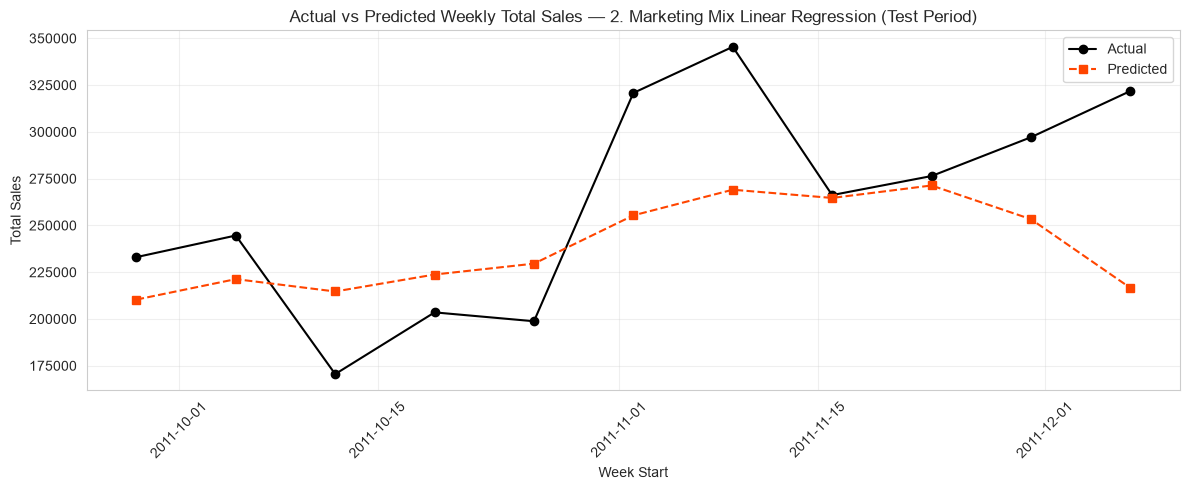

In [22]:
pred_map = {
    "1. Baseline Linear Regression": base_pred_actual,
    "2. Marketing Mix Linear Regression": mmm_pred_actual,
    "3. Ridge Regression": ridge_pred_actual,
    "4. Lasso Regression": lasso_pred_actual,
    "5. Random Forest Regressor": rf_pred_actual,
}
best_pred_actual = pred_map[best_model_name]
actual_test_sales = inverse_target(y_test.values)

actual_vs_pred_df = pd.DataFrame({
    "Week_Start": test_df["Week_Start"].values,
    "Actual_Sales": actual_test_sales,
    "Predicted_Sales": best_pred_actual,
})
print("Actual vs Predicted (chronological test period):")
display(actual_vs_pred_df)

plt.figure(figsize=(12, 5))
plt.plot(actual_vs_pred_df["Week_Start"], actual_vs_pred_df["Actual_Sales"],
         marker="o", label="Actual", color="black")
plt.plot(actual_vs_pred_df["Week_Start"], actual_vs_pred_df["Predicted_Sales"],
         marker="s", label="Predicted", color="orangered", linestyle="--")
plt.title(f"Actual vs Predicted Weekly Total Sales — {best_model_name} (Test Period)")
plt.xlabel("Week Start")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "actual_vs_predicted.png"), dpi=120)
plt.show()

In [23]:
linear_coefs = pd.Series(mmm_lr.coef_, index=mmm_predictors)
ridge_coefs = pd.Series(ridge_model.coef_, index=mmm_predictors)
lasso_coefs = pd.Series(lasso_model.coef_, index=mmm_predictors)
rf_importances = pd.Series(rf_model.feature_importances_, index=mmm_predictors)

driver_table = pd.DataFrame({
    "Feature": mmm_predictors,
    "Linear_Coefficient": linear_coefs.values,
    "Ridge_Coefficient": ridge_coefs.values,
    "Lasso_Coefficient": lasso_coefs.values,
    "RandomForest_Importance": rf_importances.values,
})
driver_table["Absolute_Contribution_Measure"] = driver_table["Ridge_Coefficient"].abs()
driver_table["Direction"] = np.where(
    driver_table["Ridge_Coefficient"] >= 0, "Positive", "Negative")
driver_table = driver_table.sort_values(
    "Absolute_Contribution_Measure", ascending=False).reset_index(drop=True)

# Focus the driver table on the core internal sales-driver variables (exclude
# month seasonality dummies from the headline table; they are technical controls)
core_driver_table = driver_table[driver_table["Feature"].isin([
    "Trend", "Avg_Unit_Price", "Holiday_Flag", "Num_Unique_Products",
    "Repeat_Customer_Rate", "Cancellation_Rate"
])].reset_index(drop=True)

print("DRIVER TABLE — relative predictive contribution (NOT financial ROI)")
display(core_driver_table)
core_driver_table.to_csv(os.path.join(OUTPUT_DIR, "MMM_Coefficients.csv"), index=False)

print("\nIMPORTANT: Regression coefficients indicate statistical association "
      "within the model and do not establish causality.")

DRIVER TABLE — relative predictive contribution (NOT financial ROI)


,Feature,Linear_Coefficient,Ridge_Coefficient,Lasso_Coefficient,RandomForest_Importance,Absolute_Contribution_Measure,Direction
0,Num_Unique_Products,109.654553,31691.573413,30881.900324,0.639008,31691.573413,Positive
1,Repeat_Customer_Rate,-184964.323095,-27229.202305,-32774.654307,0.027375,27229.202305,Negative
2,Trend,2796.848911,23378.615852,34677.525598,0.170056,23378.615852,Positive
3,Holiday_Flag,20613.621190,4449.903456,6595.191138,0.025505,4449.903456,Positive
4,Cancellation_Rate,-60271.191574,-3106.364068,-2335.696063,0.022087,3106.364068,Negative
5,Avg_Unit_Price,2944.214056,1057.717613,1108.160246,0.038434,1057.717613,Positive



IMPORTANT: Regression coefficients indicate statistical association within the model and do not establish causality.


In [24]:
def interpret_driver(feature, coef):
    direction = "positive" if coef > 0 else "negative"
    templates = {
        "Num_Unique_Products": {
            "positive": "Weeks with greater product-range breadth are associated "
                        "with higher sales, holding other model variables constant.",
            "negative": "Weeks with greater product-range breadth are associated "
                        "with lower sales, holding other model variables constant.",
        },
        "Repeat_Customer_Rate": {
            "positive": "Higher repeat-customer participation is associated with "
                        "higher weekly sales, holding other model variables constant.",
            "negative": "Higher repeat-customer participation is associated with "
                        "lower weekly sales in this sample, holding other model "
                        "variables constant.",
        },
        "Cancellation_Rate": {
            "positive": "Higher cancellation rates are associated with higher "
                        "weekly sales in this sample, holding other model "
                        "variables constant.",
            "negative": "Higher cancellation rates are associated with lower "
                        "weekly sales, holding other model variables constant.",
        },
        "Avg_Unit_Price": {
            "positive": "Weeks with higher average unit prices are associated "
                        "with higher total sales, holding other model variables "
                        "constant.",
            "negative": "Weeks with higher average unit prices are associated "
                        "with lower total sales, holding other model variables "
                        "constant, consistent with price sensitivity.",
        },
        "Holiday_Flag": {
            "positive": "Peak-season (Nov-Dec) weeks are associated with higher "
                        "sales, holding other model variables constant.",
            "negative": "Peak-season (Nov-Dec) weeks are associated with lower "
                        "sales in this sample, holding other model variables "
                        "constant.",
        },
        "Trend": {
            "positive": "Sales show an underlying upward trend over the "
                        "observed period, holding other model variables constant.",
            "negative": "Sales show an underlying downward trend over the "
                        "observed period, holding other model variables constant.",
        },
    }
    if feature in templates:
        return templates[feature][direction]
    return f"{feature} shows a {direction} association with weekly sales."

print("AUTOMATED DRIVER INTERPRETATION (based on Ridge coefficients):\n")
for _, row in core_driver_table.iterrows():
    print(f"- {row['Feature']}: {interpret_driver(row['Feature'], row['Ridge_Coefficient'])}")

print("\nNote: interpretations are statistical associations from the fitted "
      "model, not causal claims, and no percentage sales impact is invented.")

AUTOMATED DRIVER INTERPRETATION (based on Ridge coefficients):

- Num_Unique_Products: Weeks with greater product-range breadth are associated with higher sales, holding other model variables constant.
- Repeat_Customer_Rate: Higher repeat-customer participation is associated with lower weekly sales in this sample, holding other model variables constant.
- Trend: Sales show an underlying upward trend over the observed period, holding other model variables constant.
- Holiday_Flag: Peak-season (Nov-Dec) weeks are associated with higher sales, holding other model variables constant.
- Cancellation_Rate: Higher cancellation rates are associated with lower weekly sales, holding other model variables constant.
- Avg_Unit_Price: Weeks with higher average unit prices are associated with higher total sales, holding other model variables constant.

Note: interpretations are statistical associations from the fitted model, not causal claims, and no percentage sales impact is invented.


In [25]:
lag_test_df = mmm_df.copy()
for col in ["Repeat_Customer_Rate", "Num_Unique_Products", "Avg_Unit_Price"]:
    lag_test_df[f"{col}_lag1"] = lag_test_df[col].shift(1)

lag_corr = lag_test_df[["Total_Sales",
                         "Repeat_Customer_Rate_lag1",
                         "Num_Unique_Products_lag1",
                         "Avg_Unit_Price_lag1"]].corr()["Total_Sales"].drop("Total_Sales")
print("Correlation of lagged internal predictors with current-week Total_Sales:")
display(lag_corr)
print("\nThese are lagged INTERNAL sales-driver variables, not advertising "
      "adstock (no marketing-channel spend data exists in this dataset).")

Correlation of lagged internal predictors with current-week Total_Sales:


Repeat_Customer_Rate_lag1    0.286660
Num_Unique_Products_lag1     0.617010
Avg_Unit_Price_lag1         -0.376986
Name: Total_Sales, dtype: float64


These are lagged INTERNAL sales-driver variables, not advertising adstock (no marketing-channel spend data exists in this dataset).


In [26]:
print(
    "Financial ROI and monetary budget reallocation cannot be estimated "
    "because the available dataset does not contain channel-level marketing "
    "expenditure."
)
print(
    "Use the estimated relative contribution of internal sales drivers to "
    "prioritize operational and marketing actions, while treating the result "
    "as directional rather than financial ROI."
)

Financial ROI and monetary budget reallocation cannot be estimated because the available dataset does not contain channel-level marketing expenditure.
Use the estimated relative contribution of internal sales drivers to prioritize operational and marketing actions, while treating the result as directional rather than financial ROI.


In [27]:
rfm_base = cleaned_uk.dropna(subset=["CustomerID"]).copy()
reference_date = rfm_base["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = rfm_base.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Sales", "sum"),
).reset_index()

print(f"Number of customers with valid CustomerID: {len(rfm)}")
print(f"Reference date used for Recency: {reference_date.date()}")
display(rfm.describe())

# RFM scores (1-5, 5 = best) via quantile binning; guard against ties
def safe_qcut(series, q, ascending=True):
    try:
        ranks = series.rank(method="first")
        labels = list(range(1, q + 1)) if ascending else list(range(q, 0, -1))
        return pd.qcut(ranks, q, labels=labels).astype(int)
    except ValueError:
        return pd.Series([3] * len(series), index=series.index)

rfm["R_Score"] = safe_qcut(rfm["Recency"], 5, ascending=False)  # lower recency = better
rfm["F_Score"] = safe_qcut(rfm["Frequency"], 5, ascending=True)
rfm["M_Score"] = safe_qcut(rfm["Monetary"], 5, ascending=True)
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm["RFM_Sum"] = rfm[["R_Score", "F_Score", "M_Score"]].sum(axis=1)

def segment_customer(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "Potential Loyalists"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Hibernating"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

print("\nSegmentation logic: R/F/M split into quintiles (5=best). Champions = "
      "recent, frequent, high-spend; Loyal = consistently above-median on all "
      "three; Potential Loyalists = recent but low frequency (newer/growing); "
      "At Risk = infrequent-recent but historically frequent; Hibernating = "
      "long-inactive, low-frequency; Others = mixed profiles not fitting a "
      "clear archetype.")

segment_counts = rfm["Segment"].value_counts()
print("\nSegment sizes:")
display(segment_counts)

rfm.to_csv(os.path.join(OUTPUT_DIR, "RFM_Customer_Segments.csv"), index=False)

Number of customers with valid CustomerID: 3916
Reference date used for Recency: 2011-12-10


,CustomerID,Recency,Frequency,Monetary
count,3916.000000,3916.000000,3916.000000,3916.000000
mean,15561.047242,92.312564,4.233912,1850.060169
std,1576.854217,99.722949,7.155092,7432.609092
min,12346.000000,1.000000,1.000000,3.750000
25%,14207.500000,18.000000,1.000000,298.082500
50%,15567.500000,51.000000,2.000000,645.975000
75%,16913.250000,143.000000,5.000000,1567.532500
max,18287.000000,374.000000,206.000000,259657.300000



Segmentation logic: R/F/M split into quintiles (5=best). Champions = recent, frequent, high-spend; Loyal = consistently above-median on all three; Potential Loyalists = recent but low frequency (newer/growing); At Risk = infrequent-recent but historically frequent; Hibernating = long-inactive, low-frequency; Others = mixed profiles not fitting a clear archetype.

Segment sizes:


Segment
Hibernating            972
Champions              857
Loyal Customers        698
At Risk                594
Others                 520
Potential Loyalists    275
Name: count, dtype: int64

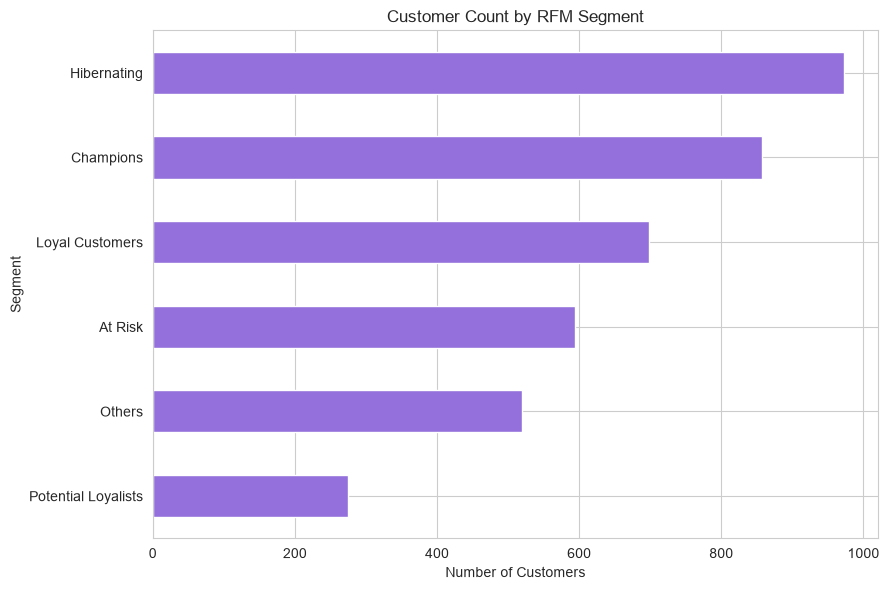

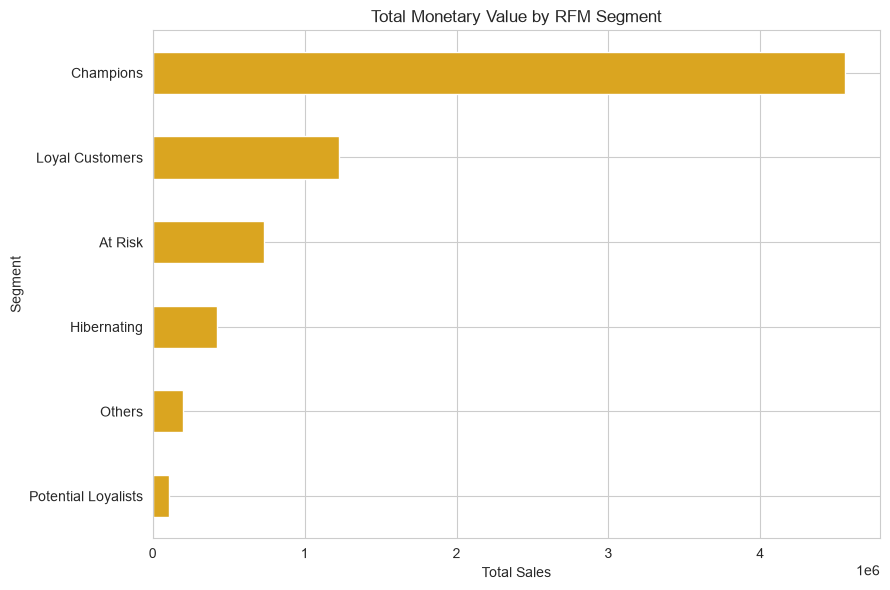

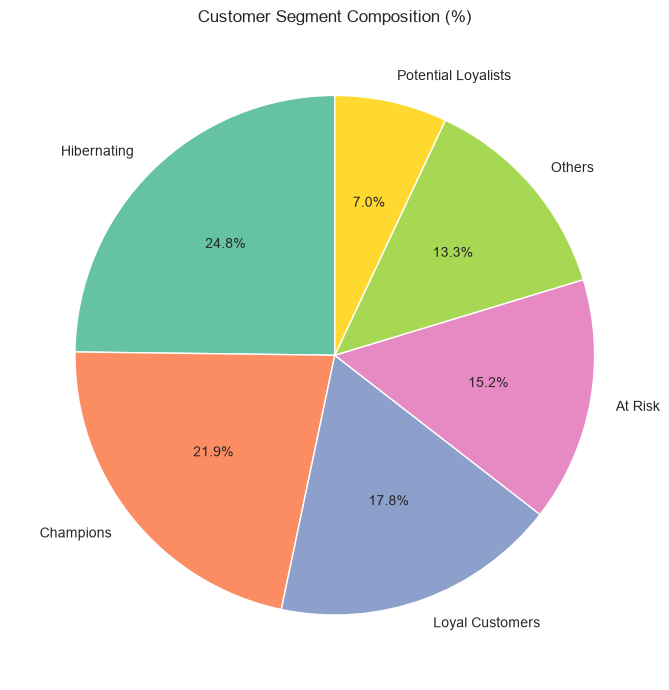

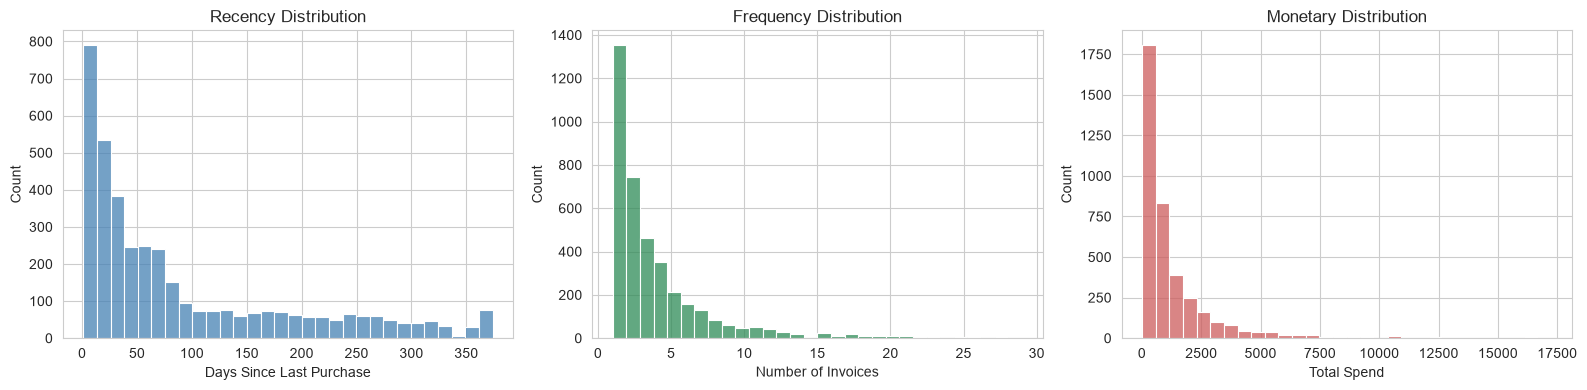


Top 5 products by segment:

Hibernating:


Description
MEDIUM CERAMIC TOP STORAGE JAR        77389.85
REGENCY CAKESTAND 3 TIER               4573.05
WHITE HANGING HEART T-LIGHT HOLDER     3885.85
PARTY BUNTING                          3442.90
SMALL POPCORN HOLDER                   3269.40
Name: Sales, dtype: float64


Champions:


Description
REGENCY CAKESTAND 3 TIER              79471.95
WHITE HANGING HEART T-LIGHT HOLDER    62186.75
JUMBO BAG RED RETROSPOT               54943.05
PARTY BUNTING                         38289.73
ASSORTED COLOUR BIRD ORNAMENT         35958.20
Name: Sales, dtype: float64


Others:


...

Description
PICNIC BASKET WICKER 60 PIECES        39619.50
WHITE HANGING HEART T-LIGHT HOLDER    18580.05
FAIRY CAKE FLANNEL ASSORTED COLOUR    13451.25
PARTY BUNTING                         12252.85
REGENCY CAKESTAND 3 TIER              10375.75
Name: Sales, dtype: float64


Loyal Customers:


Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER               13520.40
JUMBO BAG RED RETROSPOT                11968.00
WHITE HANGING HEART T-LIGHT HOLDER      8374.10
PARTY BUNTING                           8248.05
Name: Sales, dtype: float64


Potential Loyalists:


Description
METAL SIGN TAKE IT OR LEAVE IT     3890.50
VINTAGE DOILY JUMBO BAG RED        2743.24
BAKING SET SPACEBOY DESIGN         1091.25
ASSORTED COLOUR BIRD ORNAMENT      1065.64
DOORMAT KEEP CALM AND COME IN       726.60
Name: Sales, dtype: float64

In [28]:
plt.figure(figsize=(9, 6))
segment_counts.sort_values().plot(kind="barh", color="mediumpurple")
plt.title("Customer Count by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rfm_segment_counts.png"), dpi=120)
plt.show()

# 2. Segment monetary value chart
segment_monetary = rfm.groupby("Segment")["Monetary"].sum().sort_values()
plt.figure(figsize=(9, 6))
segment_monetary.plot(kind="barh", color="goldenrod")
plt.title("Total Monetary Value by RFM Segment")
plt.xlabel("Total Sales")
plt.ylabel("Segment")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rfm_segment_monetary.png"), dpi=120)
plt.show()

# 3. Segment percentage chart
segment_pct = (segment_counts / segment_counts.sum() * 100).round(1)
plt.figure(figsize=(7, 7))
plt.pie(segment_pct.values, labels=segment_pct.index, autopct="%1.1f%%",
        startangle=90, colors=sns.color_palette("Set2", len(segment_pct)))
plt.title("Customer Segment Composition (%)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rfm_segment_pct.png"), dpi=120)
plt.show()

# 4. Recency/Frequency/Monetary distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(rfm["Recency"], bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days Since Last Purchase")
sns.histplot(rfm[rfm["Frequency"] < rfm["Frequency"].quantile(0.99)]["Frequency"],
             bins=30, ax=axes[1], color="seagreen")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Invoices")
sns.histplot(rfm[rfm["Monetary"] < rfm["Monetary"].quantile(0.99)]["Monetary"],
             bins=30, ax=axes[2], color="indianred")
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Spend")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rfm_distributions.png"), dpi=120)
plt.show()

# 5. Segment-level top product analysis
rfm_data_merge = rfm_base.merge(rfm[["CustomerID", "Segment"]], on="CustomerID", how="left")
segment_top_products = {}
for seg in rfm["Segment"].unique():
    seg_products = (
        rfm_data_merge[rfm_data_merge["Segment"] == seg]
        .groupby("Description")["Sales"].sum()
        .sort_values(ascending=False).head(5)
    )
    segment_top_products[seg] = seg_products

print("\nTop 5 products by segment:")
for seg, prods in segment_top_products.items():
    print(f"\n{seg}:")
    display(prods)

In [29]:
key_segments_for_basket = ["Champions", "Loyal Customers", "At Risk", "Hibernating"]
segment_basket_links = []

for seg in key_segments_for_basket:
    if seg not in segment_top_products:
        continue
    seg_top_desc = set(segment_top_products[seg].index)
    matching_rules = rules_display[
        rules_display["antecedents"].apply(
            lambda a: any(item in seg_top_desc for item in a.split(", "))
        )
    ]
    if len(matching_rules) > 0:
        top_match = matching_rules.iloc[0]
        segment_basket_links.append({
            "Segment": seg,
            "Top_Product": list(seg_top_desc)[0] if seg_top_desc else None,
            "Linked_Rule_Antecedent": top_match["antecedents"],
            "Linked_Rule_Consequent": top_match["consequents"],
            "Lift": top_match["lift"],
        })
    else:
        segment_basket_links.append({
            "Segment": seg,
            "Top_Product": list(seg_top_desc)[0] if seg_top_desc else None,
            "Linked_Rule_Antecedent": None,
            "Linked_Rule_Consequent": None,
            "Lift": None,
        })

segment_basket_df = pd.DataFrame(segment_basket_links)
print("RFM segment <-> Market Basket linkage (based on actual generated rules):")
display(segment_basket_df)

RFM segment <-> Market Basket linkage (based on actual generated rules):


,Segment,Top_Product,Linked_Rule_Antecedent,Linked_Rule_Consequent,Lift
0,Champions,ASSORTED COLOUR BIRD ORNAMENT,"JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAGE...",JUMBO STORAGE BAG SUKI,7.635932
1,Loyal Customers,"PAPER CRAFT , LITTLE BIRDIE","JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAGE...",JUMBO STORAGE BAG SUKI,7.635932
2,At Risk,REGENCY CAKESTAND 3 TIER,NaN,NaN,NaN
3,Hibernating,MEDIUM CERAMIC TOP STORAGE JAR,NaN,NaN,NaN


In [30]:
print("Consumer Behaviour and Preference Proxies")
print(
    "The available dataset contains transaction records rather than "
    "respondent-level preference ratings. Consumer preference insights are "
    "therefore inferred from observed purchase behaviour, RFM "
    "characteristics, repeat purchasing, product frequency and basket "
    "composition rather than from survey-based perception data."
)

Consumer Behaviour and Preference Proxies
The available dataset contains transaction records rather than respondent-level preference ratings. Consumer preference insights are therefore inferred from observed purchase behaviour, RFM characteristics, repeat purchasing, product frequency and basket composition rather than from survey-based perception data.


In [31]:
strongest_rule = rules_display.iloc[0] if len(rules_display) > 0 else None
highest_value_segment = segment_monetary.idxmax()
strongest_driver_row = core_driver_table.iloc[0]

integrated_rows = []

if strongest_rule is not None:
    integrated_rows.append({
        "Analysis": "Market Basket Analysis",
        "Finding": f"Strongest association: '{strongest_rule['antecedents']}' -> "
                   f"'{strongest_rule['consequents']}'",
        "Evidence": f"Support={strongest_rule['support']:.4f}, "
                    f"Confidence={strongest_rule['confidence']:.4f}, "
                    f"Lift={strongest_rule['lift']:.2f}",
        "Marketing Action": "Bundle/cross-sell these items; place together in "
                             "merchandising and 'frequently bought together' prompts.",
        "Target Customer": "All baskets containing the antecedent product(s).",
        "Expected Strategic Role": "Increase basket size and conversion (WHAT to bundle).",
    })

integrated_rows.append({
    "Analysis": "RFM / Customer Behaviour",
    "Finding": f"'{highest_value_segment}' is the highest total-monetary-value segment.",
    "Evidence": f"Segment monetary total: {segment_monetary.max():,.2f}; "
                f"segment size: {segment_counts.get(highest_value_segment, 0)} customers.",
    "Marketing Action": "Prioritize retention offers, loyalty rewards and "
                         "personalized cross-sell for this segment; win-back "
                         "campaigns for At Risk/Hibernating segments.",
    "Target Customer": highest_value_segment,
    "Expected Strategic Role": "Improve retention and customer satisfaction (WHO to target).",
})

integrated_rows.append({
    "Analysis": "Marketing Mix / Sales-Driver Model",
    "Finding": f"Strongest internal driver of weekly sales: "
               f"{strongest_driver_row['Feature']} "
               f"({strongest_driver_row['Direction']} association).",
    "Evidence": f"Best model: {best_model_name}; Ridge coefficient: "
                f"{strongest_driver_row['Ridge_Coefficient']:.4f}; "
                f"Marketing-mix model R2: {mmm_r2:.3f} vs baseline R2: {base_r2:.3f}.",
    "Marketing Action": "Prioritize operational actions that reinforce this "
                         "driver (e.g. broaden assortment, improve repeat-"
                         "purchase experience, reduce cancellations).",
    "Target Customer": "All customers (operational/assortment-level action).",
    "Expected Strategic Role": "Improve conversion and sales consistency "
                                "(WHICH internal factors to prioritize).",
})

integrated_strategy_df = pd.DataFrame(integrated_rows)
print("INTEGRATED STRATEGY TABLE")
display(integrated_strategy_df)
integrated_strategy_df.to_csv(os.path.join(OUTPUT_DIR, "Integrated_Strategy.csv"), index=False)

INTEGRATED STRATEGY TABLE


,Analysis,Finding,Evidence,Marketing Action,Target Customer,Expected Strategic Role
0,Market Basket Analysis,Strongest association: 'PINK REGENCY TEACUP AN...,"Support=0.0333, Confidence=0.7009, Lift=14.78",Bundle/cross-sell these items; place together ...,All baskets containing the antecedent product(s).,Increase basket size and conversion (WHAT to b...
1,RFM / Customer Behaviour,'Champions' is the highest total-monetary-valu...,"Segment monetary total: 4,559,632.99; segment ...","Prioritize retention offers, loyalty rewards a...",Champions,Improve retention and customer satisfaction (W...
2,Marketing Mix / Sales-Driver Model,Strongest internal driver of weekly sales: Num...,Best model: 2. Marketing Mix Linear Regression...,Prioritize operational actions that reinforce ...,All customers (operational/assortment-level ac...,Improve conversion and sales consistency (WHIC...


In [32]:
print("BUSINESS IMPACT")
print(
    "- Conversion: cross-sell prompts from high-lift rules can nudge baskets "
    "toward known co-purchase patterns.\n"
    "- Basket Size: bundling recommended antecedent/consequent pairs targets "
    "incremental items per order.\n"
    "- Customer Retention: segment-specific actions (loyalty for Champions, "
    "win-back for At Risk/Hibernating) address different churn risk profiles.\n"
    "- Customer Satisfaction: reducing cancellation-associated friction and "
    "maintaining product-range breadth are both linked to sales performance "
    "in the fitted model.\n"
    "- Cross-Selling & Product Discovery: the association network highlights "
    "concrete product pairs for merchandising and website recommendation "
    "placement.\n"
    "- Operational Prioritization: the driver table ranks internal factors by "
    "estimated model contribution to guide where operational effort is spent "
    "first."
)
print("\nNo specific percentage sales uplift is claimed beyond what the "
      "fitted models directly support.")

BUSINESS IMPACT
- Conversion: cross-sell prompts from high-lift rules can nudge baskets toward known co-purchase patterns.
- Basket Size: bundling recommended antecedent/consequent pairs targets incremental items per order.
- Customer Retention: segment-specific actions (loyalty for Champions, win-back for At Risk/Hibernating) address different churn risk profiles.
- Customer Satisfaction: reducing cancellation-associated friction and maintaining product-range breadth are both linked to sales performance in the fitted model.
- Cross-Selling & Product Discovery: the association network highlights concrete product pairs for merchandising and website recommendation placement.
- Operational Prioritization: the driver table ranks internal factors by estimated model contribution to guide where operational effort is spent first.

No specific percentage sales uplift is claimed beyond what the fitted models directly support.


In [33]:

dashboard_full_pred = pd.Series(index=mmm_df.index, dtype=float)
train_pred_model = {
    "1. Baseline Linear Regression": baseline_lr.predict(X_train_base),
    "2. Marketing Mix Linear Regression": mmm_lr.predict(X_train_mmm),
    "3. Ridge Regression": ridge_model.predict(X_train_mmm_scaled),
    "4. Lasso Regression": lasso_model.predict(X_train_mmm_scaled),
    "5. Random Forest Regressor": rf_model.predict(X_train_mmm),
}
full_train_pred_actual = inverse_target(train_pred_model[best_model_name])
full_test_pred_actual = best_pred_actual

dashboard_data = mmm_df[[
    "Week_Number", "Week_Start", "Week_End", "Total_Sales", "Num_Orders",
    "Num_Customers", "AOV", "Total_Quantity", "Num_Unique_Products",
    "Avg_Unit_Price", "Repeat_Customer_Rate", "Cancellation_Rate",
    "Holiday_Flag", "Month", "Week_of_Year", "Weekly_Sales_Growth"
]].copy()

dashboard_data["Predicted_Sales"] = np.concatenate(
    [full_train_pred_actual, full_test_pred_actual])
dashboard_data["Sales_Variance"] = dashboard_data["Total_Sales"] - dashboard_data["Predicted_Sales"]
dashboard_data["Data_Split"] = ["Train"] * len(train_df) + ["Test"] * len(test_df)

print("Dashboard-ready dataframe:")
display(dashboard_data.head())
dashboard_data.to_csv(os.path.join(OUTPUT_DIR, "Dashboard_Data.csv"), index=False)

print(
    "\nDashboard export prepared for four conceptual Power BI pages:\n"
    "  PAGE 1 - Executive Overview      -> Dashboard_Data.csv\n"
    "  PAGE 2 - Product Affinity        -> Market_Basket_Rules.csv, Frequent_Itemsets.csv\n"
    "  PAGE 3 - Marketing Mix / Drivers -> MMM_Coefficients.csv, Model_Comparison.csv\n"
    "  PAGE 4 - Customer Behaviour      -> RFM_Customer_Segments.csv"
)


Dashboard-ready dataframe:


,Week_Number,Week_Start,Week_End,Total_Sales,Num_Orders,Num_Customers,AOV,Total_Quantity,Num_Unique_Products,Avg_Unit_Price,Repeat_Customer_Rate,Cancellation_Rate,Holiday_Flag,Month,Week_of_Year,Weekly_Sales_Growth,Predicted_Sales,Sales_Variance,Data_Split
0,1,2010-12-01,2010-12-07 23:59:59,294990.19,567,393,520.264885,124960,2281,3.808494,0.000000,0.104079,1,12,48,NaN,283236.558315,11753.631685,Train
1,2,2010-12-08,2010-12-14 23:59:59,224718.06,473,351,475.091036,99900,2193,3.698888,0.230769,0.190332,1,12,49,-23.821853,228178.421141,-3460.361141,Train
2,3,2010-12-15,2010-12-21 23:59:59,171701.30,362,246,474.312983,80917,2061,4.303825,0.422764,0.185185,1,12,50,-23.592568,183079.935203,-11378.635203,Train
3,4,2010-12-22,2010-12-28 23:59:59,13949.89,38,23,367.102368,6927,798,3.380426,0.608696,0.245283,1,12,51,-91.875490,6651.551286,7298.338714,Train
4,5,2010-12-29,2011-01-04 23:59:59,14977.32,35,33,427.923429,8329,812,3.214297,0.606061,0.109091,1,12,52,7.365148,19190.294054,-4212.974054,Train



Dashboard export prepared for four conceptual Power BI pages:
  PAGE 1 - Executive Overview      -> Dashboard_Data.csv
  PAGE 2 - Product Affinity        -> Market_Basket_Rules.csv, Frequent_Itemsets.csv
  PAGE 3 - Marketing Mix / Drivers -> MMM_Coefficients.csv, Model_Comparison.csv
  PAGE 4 - Customer Behaviour      -> RFM_Customer_Segments.csv


MARKETING ANALYTICS DASHBOARD
Rows loaded: 54
Columns loaded: 19


,Week_Number,Week_Start,Week_End,Total_Sales,Num_Orders,Num_Customers,AOV,Total_Quantity,Num_Unique_Products,Avg_Unit_Price,Repeat_Customer_Rate,Cancellation_Rate,Holiday_Flag,Month,Week_of_Year,Weekly_Sales_Growth,Predicted_Sales,Sales_Variance,Data_Split
0,1,2010-12-01,2010-12-07 23:59:59,294990.19,567,393,520.264885,124960,2281,3.808494,0.000000,0.104079,1,12,48,NaN,283236.558315,11753.631685,Train
1,2,2010-12-08,2010-12-14 23:59:59,224718.06,473,351,475.091036,99900,2193,3.698888,0.230769,0.190332,1,12,49,-23.821853,228178.421141,-3460.361141,Train
2,3,2010-12-15,2010-12-21 23:59:59,171701.30,362,246,474.312983,80917,2061,4.303825,0.422764,0.185185,1,12,50,-23.592568,183079.935203,-11378.635203,Train
3,4,2010-12-22,2010-12-28 23:59:59,13949.89,38,23,367.102368,6927,798,3.380426,0.608696,0.245283,1,12,51,-91.875490,6651.551286,7298.338714,Train
4,5,2010-12-29,2011-01-04 23:59:59,14977.32,35,33,427.923429,8329,812,3.214297,0.606061,0.109091,1,12,52,7.365148,19190.294054,-4212.974054,Train


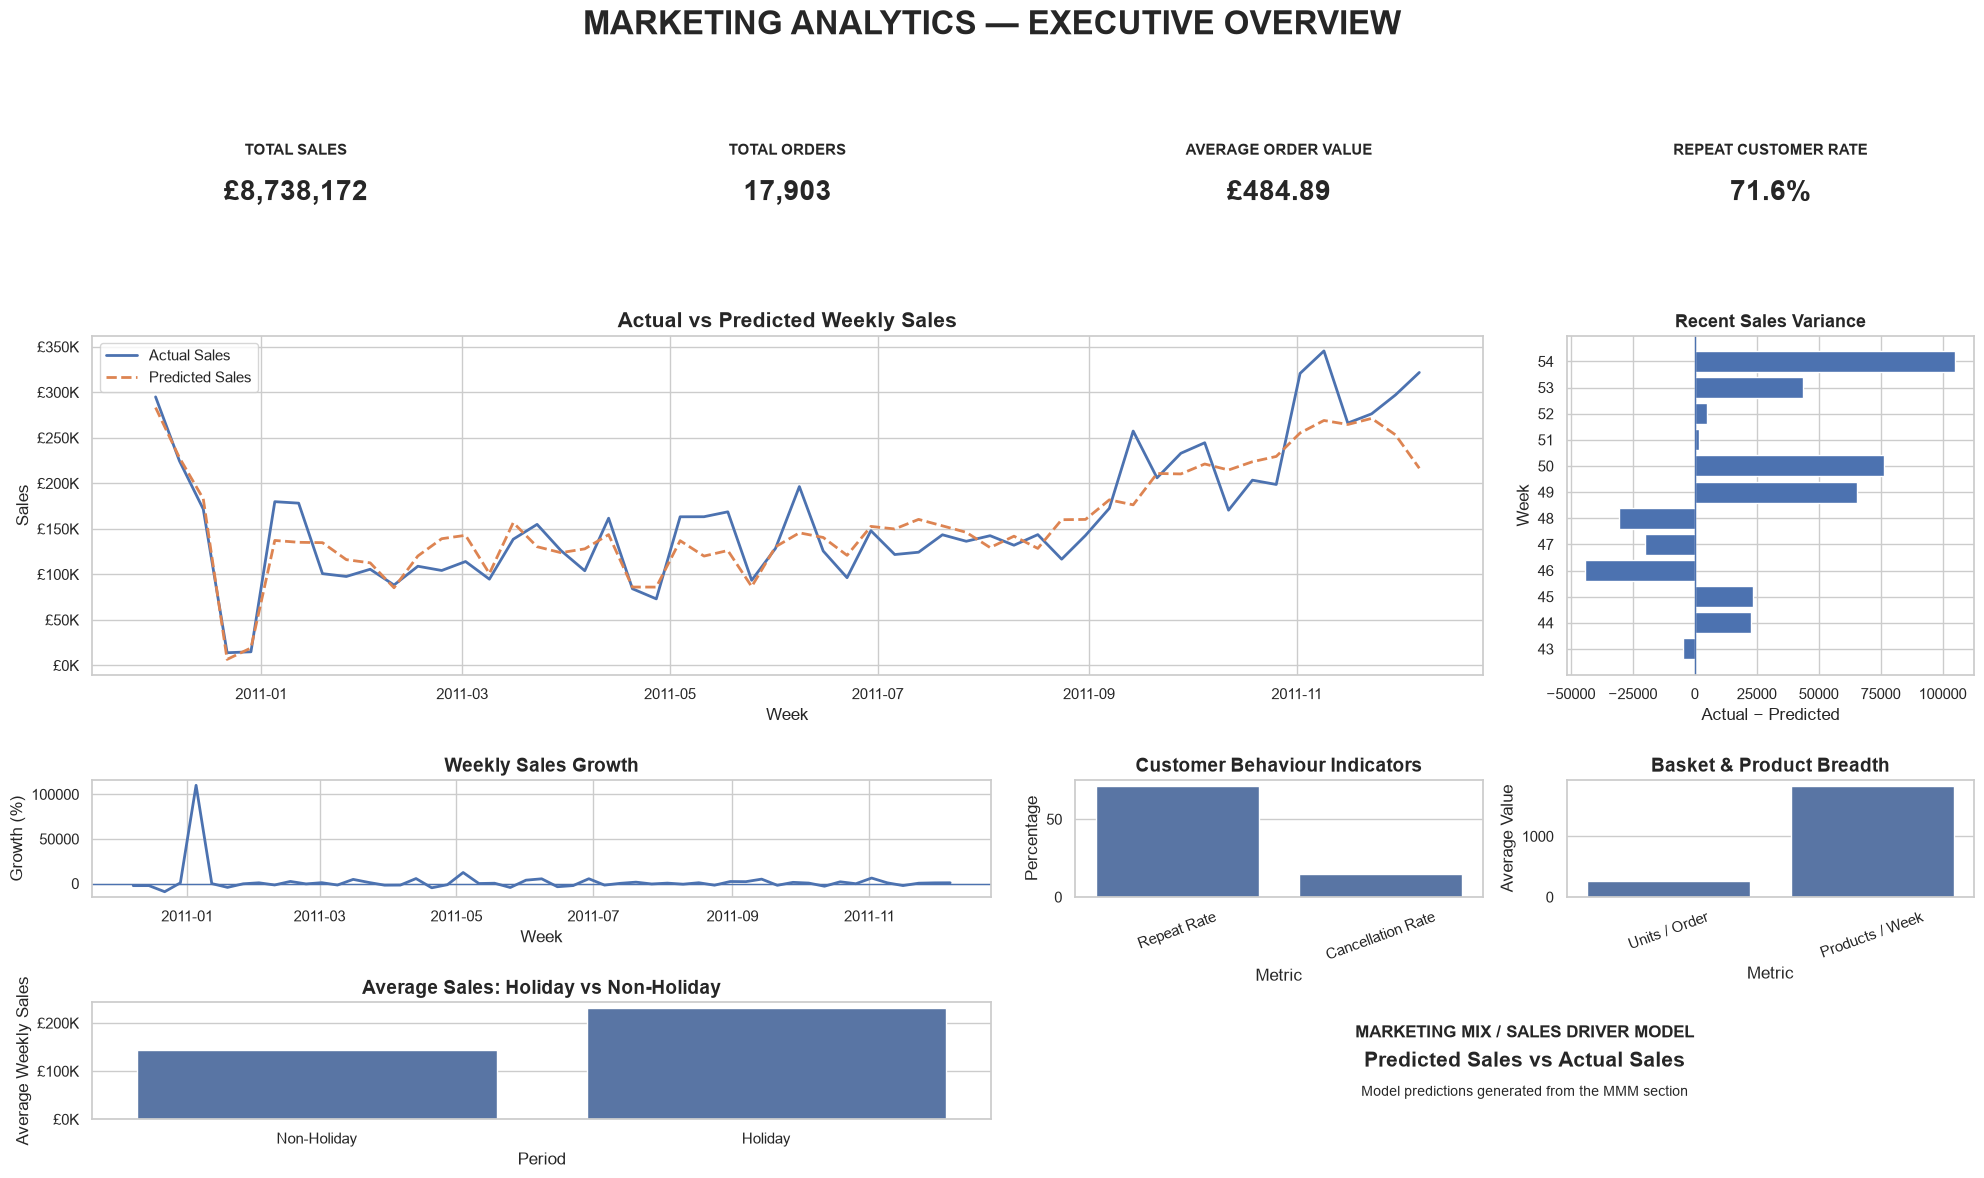

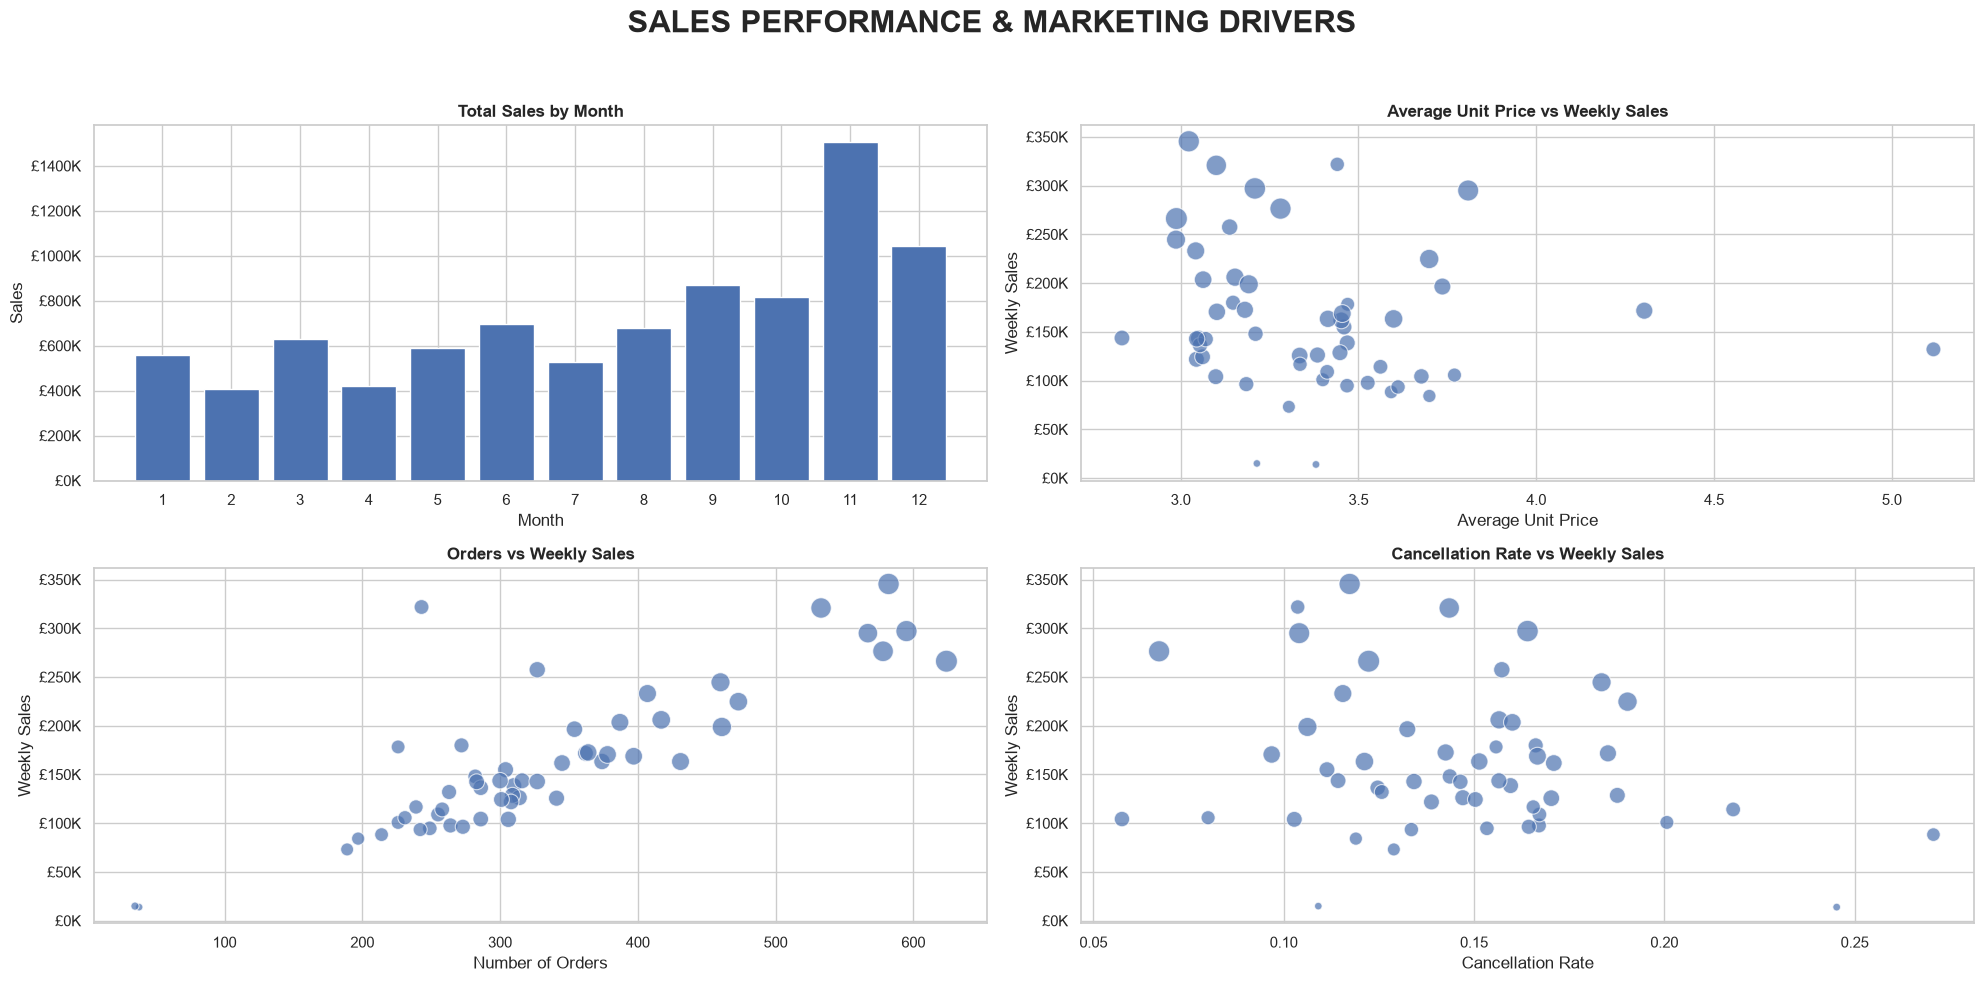

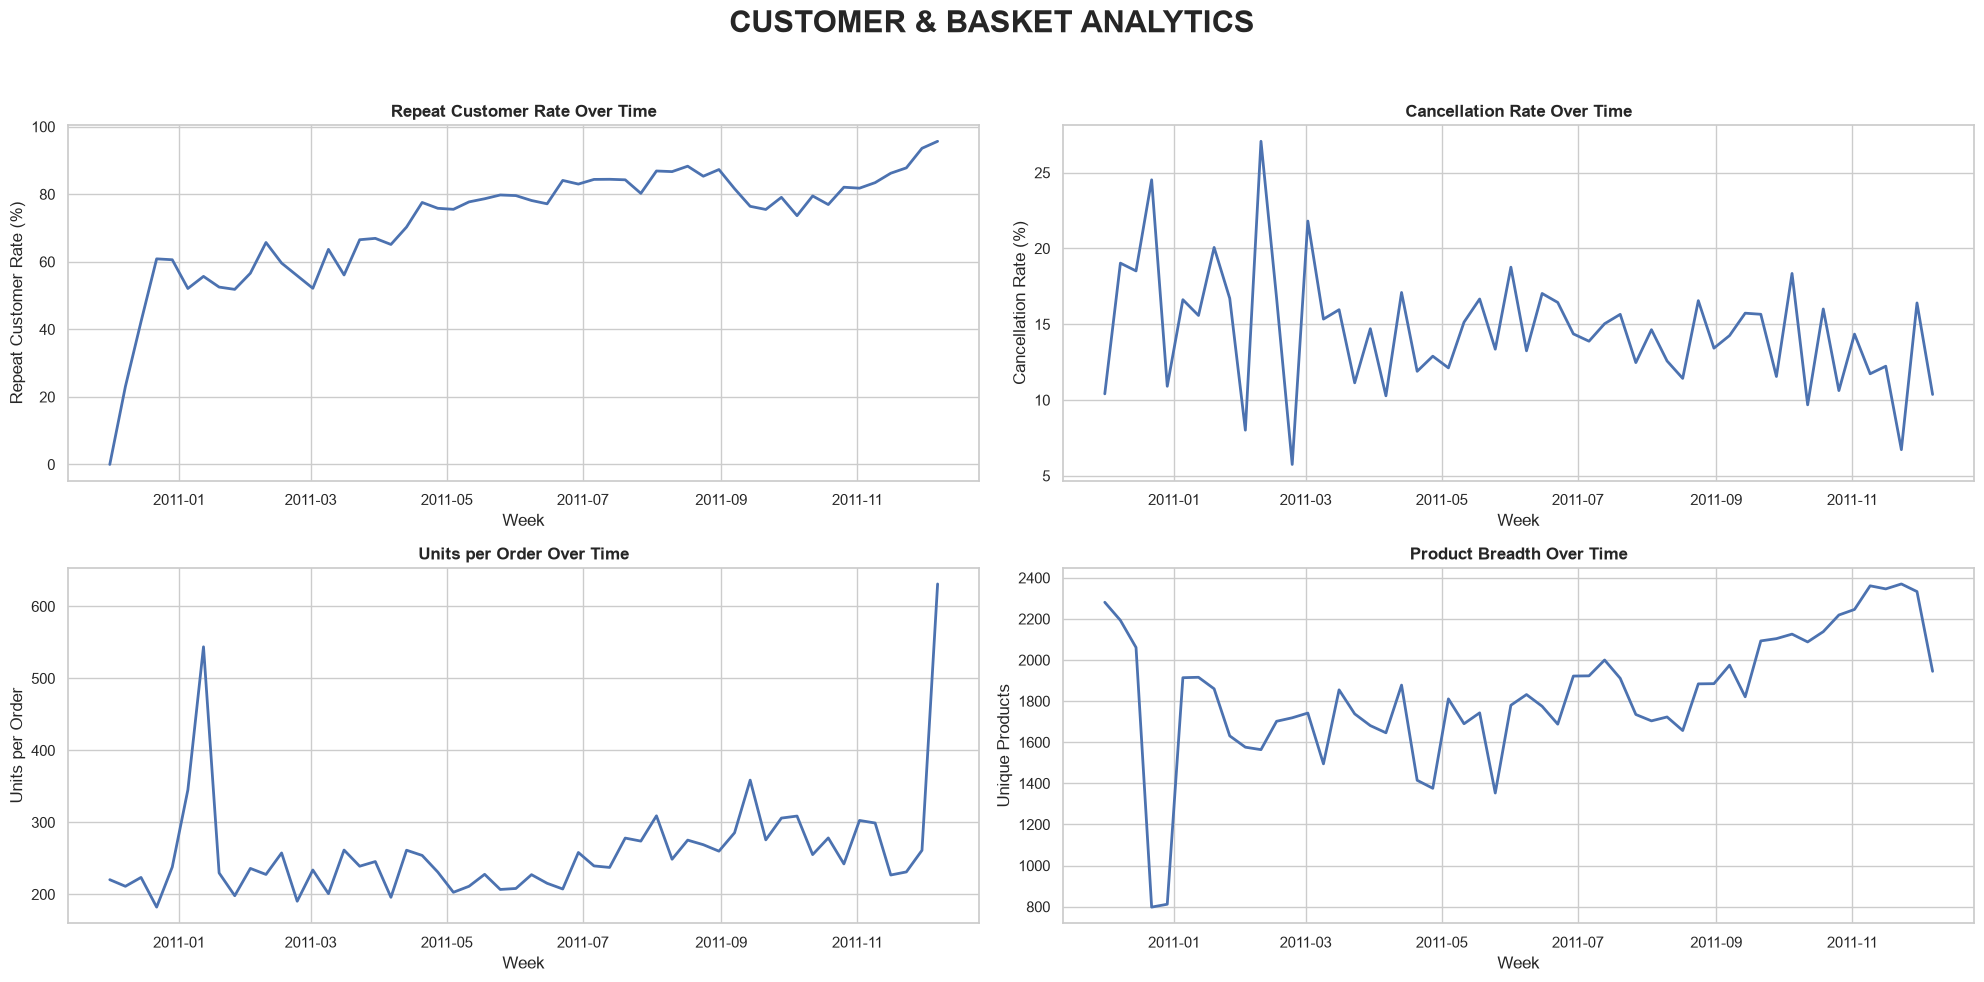

FINAL MARKETING ANALYTICS KPI SUMMARY


,KPI,Value
0,Total Sales,"£8,738,171.84"
1,Total Orders,"17,903"
2,Total Quantity,"4,639,341"
3,Average Order Value,£484.89
4,Average Repeat Customer Rate,71.59%
5,Average Cancellation Rate,14.58%
6,Average Units per Order,259.14
7,Average Unique Products per Week,1833.96
8,Average Weekly Sales,"£161,818.00"
9,Average Predicted Weekly Sales,"£157,220.90"



Dashboard data validation:
Total rows: 54
Date range: 2010-12-01 to 2011-12-09
Missing values: 1

Python dashboard generated successfully.
All dashboard visualizations are displayed directly inside Jupyter Notebook.


In [34]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")

# ============================================================
# 1. LOAD DASHBOARD DATA
# ============================================================

DATA_FILE = "Dashboard_Data.csv"

dashboard_data = pd.read_csv(DATA_FILE)

dashboard_data["Week_Start"] = pd.to_datetime(
    dashboard_data["Week_Start"]
)

dashboard_data["Week_End"] = pd.to_datetime(
    dashboard_data["Week_End"]
)

dashboard_data = (
    dashboard_data
    .sort_values("Week_Start")
    .reset_index(drop=True)
)

print("=" * 80)
print("MARKETING ANALYTICS DASHBOARD")
print("=" * 80)

print(f"Rows loaded: {len(dashboard_data):,}")
print(f"Columns loaded: {len(dashboard_data.columns)}")

display(dashboard_data.head())


# ============================================================
# 2. KPI CALCULATIONS
# ============================================================

total_sales = dashboard_data["Total_Sales"].sum()

total_orders = dashboard_data["Num_Orders"].sum()

total_quantity = dashboard_data["Total_Quantity"].sum()

average_order_value = dashboard_data["AOV"].mean()

average_repeat_rate = (
    dashboard_data["Repeat_Customer_Rate"].mean()
)

average_cancellation_rate = (
    dashboard_data["Cancellation_Rate"].mean()
)

average_units_per_order = (
    total_quantity / total_orders
)

average_unique_products = (
    dashboard_data["Num_Unique_Products"].mean()
)

total_customers = (
    dashboard_data["Num_Customers"].max()
)

average_sales = (
    dashboard_data["Total_Sales"].mean()
)

average_predicted_sales = (
    dashboard_data["Predicted_Sales"].mean()
)


# ============================================================
# 3. FORMAT FUNCTIONS
# ============================================================

def currency_format(x, pos):
    return f"£{x/1000:.0f}K"


currency_formatter = FuncFormatter(
    currency_format
)


def kpi_card(ax, title, value):

    ax.axis("off")

    ax.text(
        0.5,
        0.68,
        title,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.32,
        value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )


# ============================================================
# ============================================================
# DASHBOARD 1
# EXECUTIVE OVERVIEW
# ============================================================
# ============================================================

fig = plt.figure(
    figsize=(20, 12)
)

fig.suptitle(
    "MARKETING ANALYTICS — EXECUTIVE OVERVIEW",
    fontsize=24,
    fontweight="bold",
    y=0.98
)


# ============================================================
# KPI CARDS
# ============================================================

ax1 = plt.subplot2grid(
    (5, 4),
    (0, 0)
)

ax2 = plt.subplot2grid(
    (5, 4),
    (0, 1)
)

ax3 = plt.subplot2grid(
    (5, 4),
    (0, 2)
)

ax4 = plt.subplot2grid(
    (5, 4),
    (0, 3)
)


kpi_card(
    ax1,
    "TOTAL SALES",
    f"£{total_sales:,.0f}"
)

kpi_card(
    ax2,
    "TOTAL ORDERS",
    f"{total_orders:,.0f}"
)

kpi_card(
    ax3,
    "AVERAGE ORDER VALUE",
    f"£{average_order_value:,.2f}"
)

kpi_card(
    ax4,
    "REPEAT CUSTOMER RATE",
    f"{average_repeat_rate:.1%}"
)


# ============================================================
# ACTUAL VS PREDICTED SALES
# ============================================================

ax5 = plt.subplot2grid(
    (5, 4),
    (1, 0),
    colspan=3,
    rowspan=2
)

ax5.plot(
    dashboard_data["Week_Start"],
    dashboard_data["Total_Sales"],
    linewidth=2,
    label="Actual Sales"
)

ax5.plot(
    dashboard_data["Week_Start"],
    dashboard_data["Predicted_Sales"],
    linewidth=2,
    linestyle="--",
    label="Predicted Sales"
)

ax5.set_title(
    "Actual vs Predicted Weekly Sales",
    fontsize=15,
    fontweight="bold"
)

ax5.set_xlabel(
    "Week"
)

ax5.set_ylabel(
    "Sales"
)

ax5.yaxis.set_major_formatter(
    currency_formatter
)

ax5.legend()


# ============================================================
# SALES VARIANCE
# ============================================================

ax6 = plt.subplot2grid(
    (5, 4),
    (1, 3),
    rowspan=2
)

recent_variance = (
    dashboard_data
    .tail(12)
    .copy()
)

ax6.barh(
    recent_variance["Week_Number"].astype(str),
    recent_variance["Sales_Variance"]
)

ax6.axvline(
    0,
    linewidth=1
)

ax6.set_title(
    "Recent Sales Variance",
    fontsize=13,
    fontweight="bold"
)

ax6.set_xlabel(
    "Actual − Predicted"
)

ax6.set_ylabel(
    "Week"
)


# ============================================================
# SALES GROWTH
# ============================================================

ax7 = plt.subplot2grid(
    (5, 4),
    (3, 0),
    colspan=2
)

growth_data = dashboard_data.dropna(
    subset=["Weekly_Sales_Growth"]
)

ax7.plot(
    growth_data["Week_Start"],
    growth_data["Weekly_Sales_Growth"] * 100,
    linewidth=2
)

ax7.axhline(
    0,
    linewidth=1
)

ax7.set_title(
    "Weekly Sales Growth",
    fontsize=14,
    fontweight="bold"
)

ax7.set_xlabel(
    "Week"
)

ax7.set_ylabel(
    "Growth (%)"
)


# ============================================================
# CUSTOMER BEHAVIOUR
# ============================================================

ax8 = plt.subplot2grid(
    (5, 4),
    (3, 2)
)

behaviour_data = pd.DataFrame({
    "Metric": [
        "Repeat Rate",
        "Cancellation Rate"
    ],
    "Value": [
        average_repeat_rate * 100,
        average_cancellation_rate * 100
    ]
})

sns.barplot(
    data=behaviour_data,
    x="Metric",
    y="Value",
    ax=ax8
)

ax8.set_title(
    "Customer Behaviour Indicators",
    fontsize=14,
    fontweight="bold"
)

ax8.set_ylabel(
    "Percentage"
)

ax8.tick_params(
    axis="x",
    rotation=20
)


# ============================================================
# BASKET METRICS
# ============================================================

ax9 = plt.subplot2grid(
    (5, 4),
    (3, 3)
)

basket_data = pd.DataFrame({
    "Metric": [
        "Units / Order",
        "Products / Week"
    ],
    "Value": [
        average_units_per_order,
        average_unique_products
    ]
})

sns.barplot(
    data=basket_data,
    x="Metric",
    y="Value",
    ax=ax9
)

ax9.set_title(
    "Basket & Product Breadth",
    fontsize=14,
    fontweight="bold"
)

ax9.set_ylabel(
    "Average Value"
)

ax9.tick_params(
    axis="x",
    rotation=20
)


# ============================================================
# HOLIDAY SALES
# ============================================================

ax10 = plt.subplot2grid(
    (5, 4),
    (4, 0),
    colspan=2
)

holiday_data = (
    dashboard_data
    .groupby("Holiday_Flag")["Total_Sales"]
    .mean()
    .reset_index()
)

holiday_data["Period"] = (
    holiday_data["Holiday_Flag"]
    .map({
        0: "Non-Holiday",
        1: "Holiday"
    })
)

sns.barplot(
    data=holiday_data,
    x="Period",
    y="Total_Sales",
    ax=ax10
)

ax10.set_title(
    "Average Sales: Holiday vs Non-Holiday",
    fontsize=14,
    fontweight="bold"
)

ax10.set_ylabel(
    "Average Weekly Sales"
)

ax10.yaxis.set_major_formatter(
    currency_formatter
)


# ============================================================
# MODEL INFORMATION
# ============================================================

ax11 = plt.subplot2grid(
    (5, 4),
    (4, 2),
    colspan=2
)

ax11.axis("off")

ax11.text(
    0.5,
    0.70,
    "MARKETING MIX / SALES DRIVER MODEL",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

ax11.text(
    0.5,
    0.45,
    "Predicted Sales vs Actual Sales",
    ha="center",
    fontsize=15,
    fontweight="bold"
)

ax11.text(
    0.5,
    0.20,
    "Model predictions generated from the MMM section",
    ha="center",
    fontsize=10
)


plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()


# ============================================================
# ============================================================
# DASHBOARD 2
# SALES PERFORMANCE & DRIVERS
# ============================================================
# ============================================================

fig = plt.figure(
    figsize=(20, 10)
)

fig.suptitle(
    "SALES PERFORMANCE & MARKETING DRIVERS",
    fontsize=22,
    fontweight="bold",
    y=0.98
)


# ============================================================
# SALES BY MONTH
# ============================================================

ax1 = plt.subplot2grid(
    (2, 2),
    (0, 0)
)

monthly_sales = (
    dashboard_data
    .groupby("Month")["Total_Sales"]
    .sum()
    .reset_index()
)

ax1.bar(
    monthly_sales["Month"].astype(str),
    monthly_sales["Total_Sales"]
)

ax1.set_title(
    "Total Sales by Month",
    fontweight="bold"
)

ax1.set_xlabel(
    "Month"
)

ax1.set_ylabel(
    "Sales"
)

ax1.yaxis.set_major_formatter(
    currency_formatter
)


# ============================================================
# PRICE VS SALES
# ============================================================

ax2 = plt.subplot2grid(
    (2, 2),
    (0, 1)
)

sns.scatterplot(
    data=dashboard_data,
    x="Avg_Unit_Price",
    y="Total_Sales",
    size="Num_Orders",
    sizes=(30, 250),
    alpha=0.7,
    ax=ax2,
    legend=False
)

ax2.set_title(
    "Average Unit Price vs Weekly Sales",
    fontweight="bold"
)

ax2.set_xlabel(
    "Average Unit Price"
)

ax2.set_ylabel(
    "Weekly Sales"
)

ax2.yaxis.set_major_formatter(
    currency_formatter
)


# ============================================================
# ORDERS VS SALES
# ============================================================

ax3 = plt.subplot2grid(
    (2, 2),
    (1, 0)
)

sns.scatterplot(
    data=dashboard_data,
    x="Num_Orders",
    y="Total_Sales",
    size="Num_Customers",
    sizes=(30, 250),
    alpha=0.7,
    ax=ax3,
    legend=False
)

ax3.set_title(
    "Orders vs Weekly Sales",
    fontweight="bold"
)

ax3.set_xlabel(
    "Number of Orders"
)

ax3.set_ylabel(
    "Weekly Sales"
)

ax3.yaxis.set_major_formatter(
    currency_formatter
)


# ============================================================
# CANCELLATION VS SALES
# ============================================================

ax4 = plt.subplot2grid(
    (2, 2),
    (1, 1)
)

sns.scatterplot(
    data=dashboard_data,
    x="Cancellation_Rate",
    y="Total_Sales",
    size="Num_Orders",
    sizes=(30, 250),
    alpha=0.7,
    ax=ax4,
    legend=False
)

ax4.set_title(
    "Cancellation Rate vs Weekly Sales",
    fontweight="bold"
)

ax4.set_xlabel(
    "Cancellation Rate"
)

ax4.set_ylabel(
    "Weekly Sales"
)

ax4.yaxis.set_major_formatter(
    currency_formatter
)


plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()


# ============================================================
# ============================================================
# DASHBOARD 3
# CUSTOMER & BASKET ANALYTICS
# ============================================================
# ============================================================

fig = plt.figure(
    figsize=(20, 10)
)

fig.suptitle(
    "CUSTOMER & BASKET ANALYTICS",
    fontsize=22,
    fontweight="bold",
    y=0.98
)


# ============================================================
# REPEAT CUSTOMER RATE BY WEEK
# ============================================================

ax1 = plt.subplot2grid(
    (2, 2),
    (0, 0)
)

ax1.plot(
    dashboard_data["Week_Start"],
    dashboard_data["Repeat_Customer_Rate"] * 100,
    linewidth=2
)

ax1.set_title(
    "Repeat Customer Rate Over Time",
    fontweight="bold"
)

ax1.set_xlabel(
    "Week"
)

ax1.set_ylabel(
    "Repeat Customer Rate (%)"
)


# ============================================================
# CANCELLATION RATE BY WEEK
# ============================================================

ax2 = plt.subplot2grid(
    (2, 2),
    (0, 1)
)

ax2.plot(
    dashboard_data["Week_Start"],
    dashboard_data["Cancellation_Rate"] * 100,
    linewidth=2
)

ax2.set_title(
    "Cancellation Rate Over Time",
    fontweight="bold"
)

ax2.set_xlabel(
    "Week"
)

ax2.set_ylabel(
    "Cancellation Rate (%)"
)


# ============================================================
# UNITS PER ORDER
# ============================================================

ax3 = plt.subplot2grid(
    (2, 2),
    (1, 0)
)

weekly_units_per_order = (
    dashboard_data["Total_Quantity"]
    / dashboard_data["Num_Orders"]
)

ax3.plot(
    dashboard_data["Week_Start"],
    weekly_units_per_order,
    linewidth=2
)

ax3.set_title(
    "Units per Order Over Time",
    fontweight="bold"
)

ax3.set_xlabel(
    "Week"
)

ax3.set_ylabel(
    "Units per Order"
)


# ============================================================
# UNIQUE PRODUCTS
# ============================================================

ax4 = plt.subplot2grid(
    (2, 2),
    (1, 1)
)

ax4.plot(
    dashboard_data["Week_Start"],
    dashboard_data["Num_Unique_Products"],
    linewidth=2
)

ax4.set_title(
    "Product Breadth Over Time",
    fontweight="bold"
)

ax4.set_xlabel(
    "Week"
)

ax4.set_ylabel(
    "Unique Products"
)


plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()


# ============================================================
# FINAL KPI TABLE
# ============================================================

final_kpis = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Orders",
        "Total Quantity",
        "Average Order Value",
        "Average Repeat Customer Rate",
        "Average Cancellation Rate",
        "Average Units per Order",
        "Average Unique Products per Week",
        "Average Weekly Sales",
        "Average Predicted Weekly Sales"
    ],

    "Value": [
        f"£{total_sales:,.2f}",
        f"{total_orders:,.0f}",
        f"{total_quantity:,.0f}",
        f"£{average_order_value:,.2f}",
        f"{average_repeat_rate:.2%}",
        f"{average_cancellation_rate:.2%}",
        f"{average_units_per_order:.2f}",
        f"{average_unique_products:.2f}",
        f"£{average_sales:,.2f}",
        f"£{average_predicted_sales:,.2f}"
    ]
})


print("=" * 80)
print("FINAL MARKETING ANALYTICS KPI SUMMARY")
print("=" * 80)

display(final_kpis)


# ============================================================
# DATA QUALITY CHECK
# ============================================================

print("\nDashboard data validation:")

print(
    f"Total rows: {len(dashboard_data):,}"
)

print(
    f"Date range: "
    f"{dashboard_data['Week_Start'].min().date()} "
    f"to "
    f"{dashboard_data['Week_End'].max().date()}"
)

print(
    f"Missing values: "
    f"{dashboard_data.isna().sum().sum():,}"
)

print("\nPython dashboard generated successfully.")
print("All dashboard visualizations are displayed directly inside Jupyter Notebook.")